# 🏦 JPMorgan Chase: ¿a quién le llega esta queja?

**Taller de Procesamiento de Lenguaje Natural: de las palabras a las decisiones**

> ℹ️ Caso hipotético con fines educativos. Las quejas son reales y públicas: vienen de la base del regulador de
> EE. UU. (CFPB) contra JPMorgan Chase. El correo y las cifras de operación del caso son ilustrativos.

---

## 📩 Tu primer día

Hoy empiezas en el equipo de analítica de **JPMorgan Chase**. Antes del café ya tienes un correo de la gerente de
Servicio al Cliente:

> *"Bienvenido/a. Tenemos un problema urgente. Recibimos **decenas de miles de quejas al año** por la web, la app, el
> correo y el portal del regulador. Hoy un equipo de analistas las lee **una por una** y las reenvía al área que debe
> resolverlas. Casi **1 de cada 3 llega al área equivocada**, cada reenvío nos cuesta días y el regulador (CFPB) nos da
> solo **15 días** para responder. Ah, y la categoría que marca el cliente en el formulario no es confiable.*
>
> *¿Puedes construir algo que lea las quejas y las envíe solo al equipo correcto?"*

Ese es tu reto. Al final de este notebook tendrás un sistema que lo hace, y lo habrás comparado con un modelo de
inteligencia artificial moderno.

## 🎯 Lo que vas a aprender

1. Hacer un **análisis exploratorio (EDA)** completo de texto y metadatos, y detectar sesgos en los datos.
2. Limpiar texto real, con ruido y datos personales enmascarados.
3. Preprocesar lenguaje: tokenización, *stop words*, lematización y etiquetado gramatical (POS).
4. Convertir texto en números con **Bag of Words** y **TF-IDF**, sin **fuga de datos**.
5. Descubrir temas **sin etiquetas** con **LDA**, elegir el mejor modelo con la **perplejidad** y *ver* los temas en
   un mapa 2D.
6. Usar esos temas para entrenar una **Regresión Logística**.
7. Comparar tu modelo con un modelo **zero-shot** de Hugging Face (DeBERTa-v3), que no necesita entrenamiento.
8. Publicar los dos modelos en una **app web** con Gradio.

## 🗺️ El recorrido

```
 📩 Quejas (JSON)
     │
     ▼
 Paso 1: Explorar ──► Paso 2: Limpiar ──► Paso 3: Entender el lenguaje ──► Paso 4: Texto a números
 (EDA completo)                           (spaCy: lemas y POS)              (TF-IDF, sin fuga de datos)
                                                                                   │
                                                                                   ▼
                                  Paso 6: Clasificar ◄─────────────── Paso 5: Descubrir temas
                                  (Regresión Logística)                    (LDA + mapa t-SNE)
                                         │
                                         ▼
                        Paso 7: Tu modelo  vs  DeBERTa-v3 zero-shot
                                         │
                                         ▼
                              Paso 8: Tu recomendación al banco
                                         │
                                         ▼
                              Paso 9: App web con Gradio
```

## ⚙️ Antes de ejecutar (Kaggle)

- **Accelerator:** GPU T4 (o P100). Solo hace falta en el paso 7.
- **Internet:** On (para descargar modelos).
- **Input:** *Add Input* → busca el dataset público
  [`sebastianramirezesc/complaints-json`](https://www.kaggle.com/datasets/sebastianramirezesc/complaints-json).
  Si no lo agregas, el notebook lo descarga solo.
- ⏳ El notebook completo tarda unos 20 minutos.

## 🧰 Paso 0: Preparar la caja de herramientas

Todo el taller usa Python:

| Librería | Para qué la usamos |
| --- | --- |
| `pandas`, `numpy` | Tablas y arreglos numéricos |
| `spaCy` | Entender el lenguaje: palabras, lemas y funciones gramaticales |
| `scikit-learn` | Vectorizar texto, LDA, t-SNE, Regresión Logística y métricas |
| `matplotlib`, `wordcloud` | Gráficas y nubes de palabras |
| `transformers` | Modelos pre-entrenados de Hugging Face (paso 7) |
| `gradio` | App web para probar los modelos (paso 9) |

In [1]:
# spaCy necesita un modelo de idioma. Las quejas están en inglés, así que usamos el modelo pequeño de inglés.
# Si ya está instalado, esta línea no hace nada.
!python -c "import en_core_web_sm" 2>/dev/null || python -m spacy download en_core_web_sm

In [2]:
import glob
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from matplotlib.patches import Patch
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Estilo de las gráficas: fondo limpio y cuadrícula suave
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
    "font.size": 11,
})
pd.set_option("display.max_colwidth", 200)

# Las 5 áreas del banco que resuelven quejas.
# - En inglés: se las damos al modelo de Hugging Face, porque las quejas están en inglés.
# - En español: las usamos en tablas y gráficas.
CATEGORIAS_EN = [
    "Mortgages and Loans",
    "Accounts and Transactions",
    "Credit Reporting and Disputes",
    "Credit Cards and Fees",
    "Fraud and Transaction Disputes",
]
CATEGORIAS = [
    "Hipotecas y préstamos",
    "Cuentas y transacciones",
    "Reportes de crédito",
    "Tarjetas de crédito",
    "Fraude y disputas",
]

# Un color fijo por categoría (o por tema), el mismo en todas las gráficas
COLORES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
AZUL = COLORES[0]
GRIS = "#b9b8b1"


def dibujar_heatmap(matriz, filas, columnas, titulo, etiqueta_barra, ax=None):
    # Matriz de proporciones (0 a 1) con el porcentaje escrito en cada celda
    if ax is None:
        fig, ax = plt.subplots(figsize=(1.3 * len(columnas) + 3, 0.55 * len(filas) + 2))
    imagen = ax.imshow(matriz, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(columnas)), columnas, rotation=30, ha="right")
    ax.set_yticks(range(len(filas)), filas)
    for fila in range(len(filas)):
        for columna in range(len(columnas)):
            valor = matriz[fila][columna]
            ax.text(columna, fila, f"{valor:.0%}", ha="center", va="center", fontsize=9,
                    color="white" if valor > 0.5 else "black")
    ax.grid(False)
    ax.set_title(titulo)
    plt.colorbar(imagen, ax=ax, label=etiqueta_barra)
    return ax

## 🔍 Paso 1: Conocer las quejas (análisis exploratorio)

Antes de construir cualquier modelo, un buen científico de datos **lee sus datos**. A esto se le llama **EDA**
(*Exploratory Data Analysis*). Buscamos responder: ¿qué hay?, ¿qué falta?, ¿qué sesgos tiene?, ¿qué nos sugiere para
los pasos siguientes?

### Texto: un dato no estructurado

Una queja no tiene columnas ni tipos fijos: es **texto libre**. Los modelos de machine learning solo entienden
números, así que todo este taller trata de una misma idea: **transformar texto en números sin perder su significado.**

El archivo sigue el formato de la base pública de quejas del regulador de EE. UU. (CFPB). Cada registro es un JSON
con un campo `_source` que guarda la queja y sus **metadatos** (datos sobre la queja).

In [3]:
def buscar_archivo_quejas():
    # 1) Si el dataset se agregó como Input del notebook, está en /kaggle/input
    encontrados = glob.glob("/kaggle/input/**/complaints.json", recursive=True)
    if encontrados:
        return encontrados[0]
    # 2) Si no, lo descargamos del dataset público de Kaggle
    import kagglehub
    carpeta = kagglehub.dataset_download("sebastianramirezesc/complaints-json")
    return glob.glob(carpeta + "/**/complaints.json", recursive=True)[0]


ruta = buscar_archivo_quejas()

# json_normalize "aplana" el JSON: el campo anidado _source.product pasa a ser la columna "_source.product"
registros = pd.json_normalize(json.load(open(ruta)))
print(f"Registros en el archivo: {len(registros):,}")
registros.iloc[:3, :8]

Registros en el archivo: 78,313


,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems"


In [4]:
# Nos quedamos con el texto y los metadatos útiles, con nombres en español
COLUMNAS = {
    "_source.complaint_what_happened": "texto_original",
    "_source.product": "producto",
    "_source.sub_product": "subproducto",
    "_source.issue": "problema",
    "_source.date_received": "fecha",
    "_source.state": "estado",
    "_source.submitted_via": "canal",
    "_source.company_response": "respuesta",
    "_source.timely": "a_tiempo",
    "_source.tags": "etiquetas",
    "_source.consumer_consent_provided": "consentimiento",
}
todas = registros.rename(columns=COLUMNAS)[list(COLUMNAS.values())]
todas["fecha"] = pd.to_datetime(todas.fecha, utc=True).dt.tz_localize(None)
todas["tiene_texto"] = todas.texto_original.str.strip() != ""

# Mapa de los datos: tipo, % vacío y cantidad de valores distintos de cada columna
vacio = todas.apply(lambda columna: columna.isna() | (columna.astype(str).str.strip() == ""))
pd.DataFrame({
    "tipo": todas.dtypes.astype(str),
    "% vacío": (vacio.mean() * 100).round(1),
    "valores distintos": todas.nunique(),
    "ejemplo": todas.iloc[1],
})

,tipo,% vacío,valores distintos,ejemplo
texto_original,object,73.1,20931,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent ...
producto,object,0.0,17,Debt collection
subproducto,object,13.5,72,Credit card debt
problema,object,0.0,154,Written notification about debt
fecha,datetime64[ns],0.0,3444,2019-05-01 17:00:00
estado,object,2.5,62,GA
canal,object,0.0,6,Web
respuesta,object,0.0,8,Closed with explanation
a_tiempo,object,0.0,2,Yes
etiquetas,object,86.1,3,Servicemember


👀 **Qué observar:** `texto_original` está vacío en ~73 % de los registros. `etiquetas` también está casi vacío, pero
eso es normal: solo se marca cuando el cliente es un adulto mayor o un militar.

### ¿Por qué 3 de cada 4 quejas no tienen texto?

Antes de descartarlas, preguntemos **por qué** faltan. Si las quejas sin texto fueran distintas de las demás,
descartarlas sesgaría nuestra muestra.

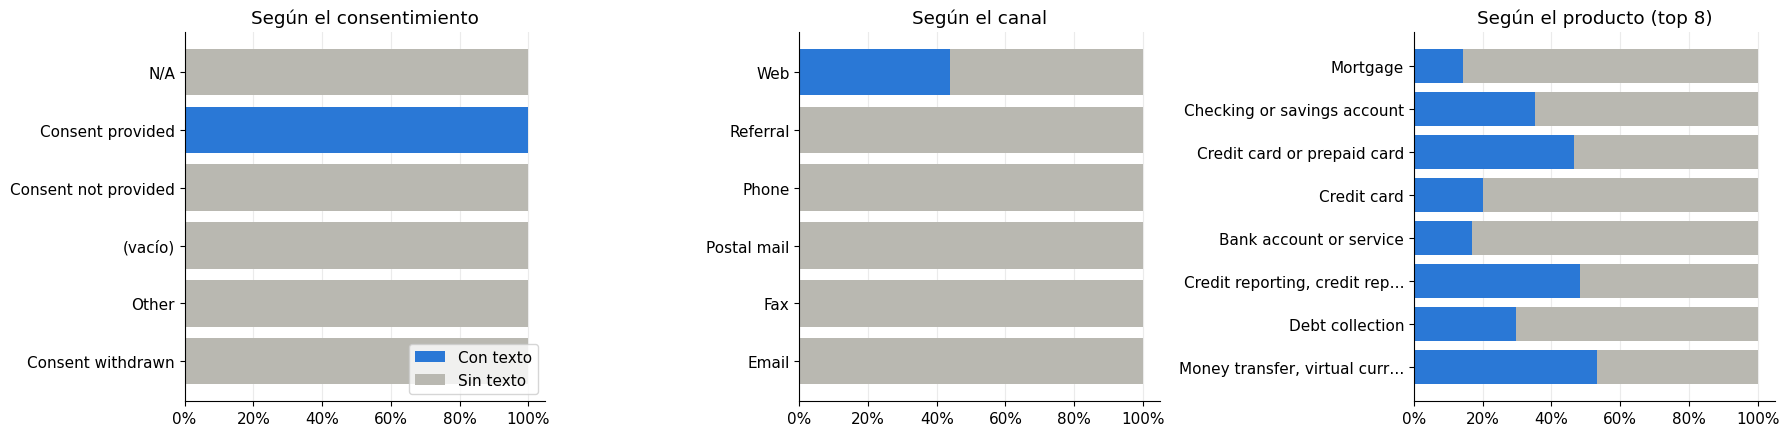

In [5]:
fig, ejes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, columna, titulo in zip(ejes, ["consentimiento", "canal", "producto"],
                               ["Según el consentimiento", "Según el canal", "Según el producto (top 8)"]):
    # Proporción de quejas con y sin texto dentro de cada grupo (cada fila suma 100 %)
    grupo = todas[columna].fillna("(vacío)")
    tabla = pd.crosstab(grupo, todas.tiene_texto, normalize="index").reindex(columns=[True, False], fill_value=0)
    tabla = tabla.loc[grupo.value_counts().index[:8]]
    tabla.index = [n if len(n) <= 30 else n[:28] + "…" for n in tabla.index]   # acortamos nombres largos
    ax.barh(tabla.index, tabla[True], color=AZUL, label="Con texto")
    ax.barh(tabla.index, tabla[False], left=tabla[True], color=GRIS, label="Sin texto")
    ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    ax.set_title(titulo)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ejes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

👀 **Qué observar:**

- **El consentimiento lo explica todo:** el CFPB solo publica la narración cuando el cliente **autoriza**
  (`Consent provided`). Los textos no "se perdieron"; el cliente decidió no compartirlos.
- El texto casi nunca llega por teléfono, correo postal o *referral*: esas quejas no tienen narración pública.
- Al quedarnos solo con quejas con texto, estudiamos a los clientes que **escriben por la web y dan consentimiento**.
  Nuestras conclusiones valen para ese grupo. Esto se llama **sesgo de selección**, y siempre hay que declararlo.

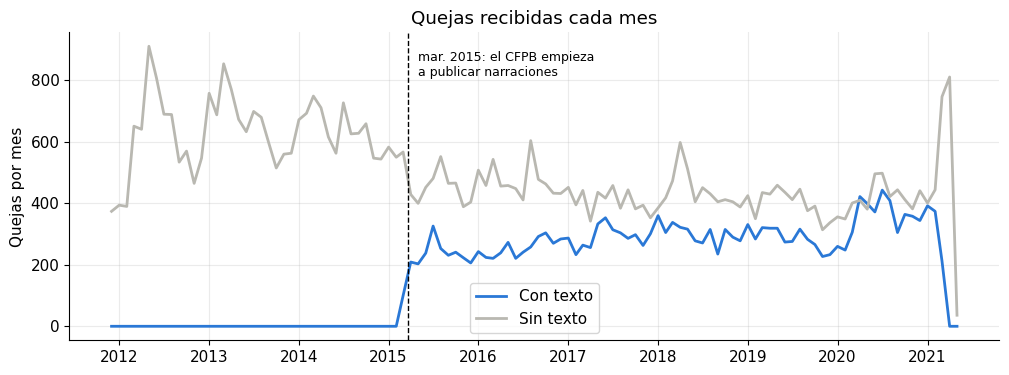

In [6]:
# ¿Cuántas quejas llegan cada mes, con y sin texto?
por_mes = (todas.groupby([pd.Grouper(key="fecha", freq="MS"), "tiene_texto"])   # MS = inicio de cada mes
                .size()
                .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(por_mes.index, por_mes[True], color=AZUL, linewidth=2, label="Con texto")
ax.plot(por_mes.index, por_mes[False], color=GRIS, linewidth=2, label="Sin texto")
ax.axvline(pd.Timestamp("2015-03-19"), color="black", linestyle="--", linewidth=1)
ax.text(pd.Timestamp("2015-05-01"), ax.get_ylim()[1] * 0.85,
        "mar. 2015: el CFPB empieza\na publicar narraciones", fontsize=9)
ax.set_ylabel("Quejas por mes")
ax.set_title("Quejas recibidas cada mes")
ax.legend()
plt.show()

👀 **Qué observar:** antes de marzo de 2015 **no existe ninguna narración**: el CFPB no las publicaba. El tiempo
también filtra los datos. Nuestro modelo aprenderá de quejas de 2015 en adelante.

### Nos quedamos con las quejas con texto

In [7]:
quejas = todas[todas.tiene_texto].reset_index(drop=True)
print(f"Quejas con texto: {len(quejas):,} de {len(todas):,} ({len(quejas) / len(todas):.0%})")

print("\n📩 Así se ve una queja real:\n")
print(quejas.texto_original[0][:800])

Quejas con texto: 21,072 de 78,313 (27%)

📩 Así se ve una queja real:

Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. 
In 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. 
I have a right to know this information as a consumer. 

Chase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.


### ¿Contra qué nos vamos a medir?

No tenemos una "verdad" perfecta. Lo más parecido es lo que marcó el cliente en `producto` y `problema`, pero los
clientes se equivocan: una queja de fraude con tarjeta puede quedar marcada como "tarjeta de crédito". A esto se le
llama **etiqueta ruidosa**.

Construimos una **categoría de referencia** con reglas simples, que se revisan en orden. Por ejemplo, si el problema
menciona fraude, la queja va a *Fraude*, sin importar el producto.

> ⚠️ **Importante:** esta referencia **solo sirve para evaluar**. Nuestro modelo nunca la verá mientras aprende.
> Aprenderá de los temas que descubra LDA en el paso 5, como si no tuviéramos ninguna etiqueta.

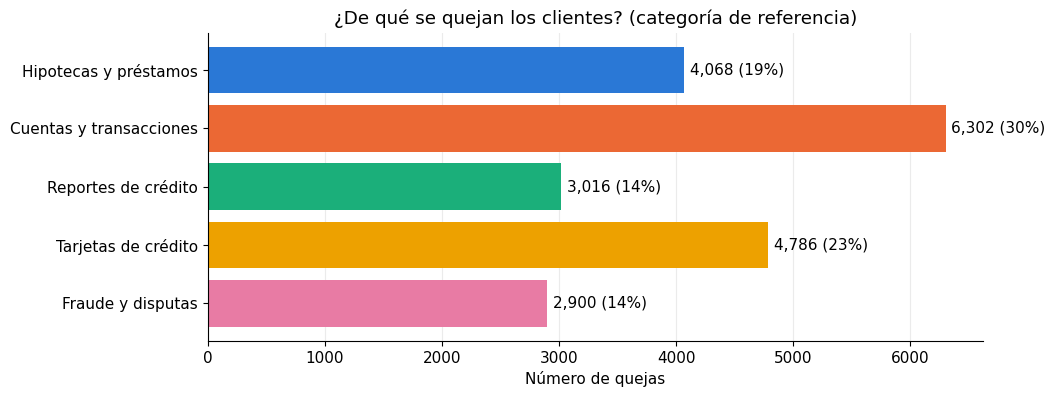

In [8]:
# Palabras en el campo "problema" que indican fraude o disputa de un cobro
SENALES_DE_FRAUDE = ["fraud", "scam", "identity theft", "unauthorized",
                     "purchase shown on your statement", "billing dispute"]


def categoria_de_referencia(producto, problema):
    # Devuelve el número de la categoría (índice en CATEGORIAS). Las reglas se revisan en orden.
    producto, problema = str(producto).lower(), str(problema).lower()

    if any(senal in problema for senal in SENALES_DE_FRAUDE):
        return 4  # Fraude y disputas
    if "credit reporting" in producto or "debt collection" in producto:
        return 2  # Reportes de crédito
    if "credit card" in producto or "prepaid card" in producto:
        return 3  # Tarjetas de crédito
    if "mortgage" in producto or "loan" in producto:
        return 0  # Hipotecas y préstamos
    return 1      # Cuentas y transacciones (todo lo demás)


quejas["categoria_ref"] = [categoria_de_referencia(prod, prob)
                           for prod, prob in zip(quejas.producto, quejas.problema)]

# ¿Cuántas quejas hay de cada categoría?
conteo = quejas.categoria_ref.value_counts().sort_index()

fig, ax = plt.subplots()
barras = ax.barh(CATEGORIAS, conteo.values, color=COLORES)
ax.bar_label(barras, labels=[f"{n:,} ({n / len(quejas):.0%})" for n in conteo.values], padding=4)
ax.invert_yaxis()                     # la primera categoría arriba
ax.grid(axis="y", visible=False)
ax.set_xlabel("Número de quejas")
ax.set_title("¿De qué se quejan los clientes? (categoría de referencia)")
plt.show()

👀 **Qué observar:** las categorías no tienen el mismo tamaño. Un modelo "perezoso" que siempre respondiera
*Cuentas y transacciones* ya acertaría cerca del 30 % de las veces. Por eso, además del *accuracy*, usaremos el
**F1** (paso 6).

### Del producto a la categoría

Veamos qué productos marcan los clientes y cómo nuestras reglas los convierten en categorías.

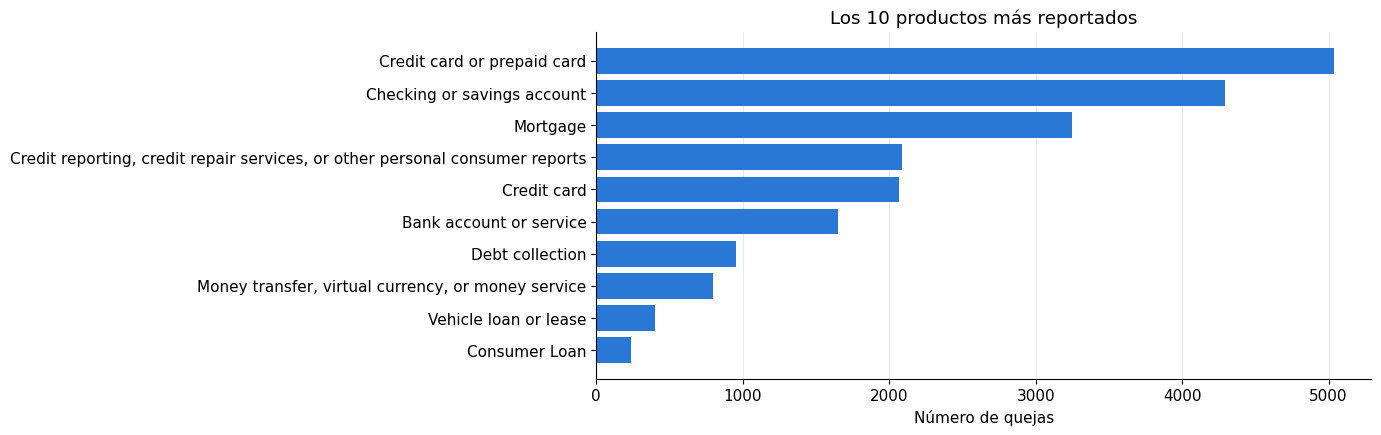

,subproductos más comunes
producto,
Credit card or prepaid card,"General-purpose credit card or charge card, Store credit card, General-purpose prepaid card"
Checking or savings account,"Checking account, Other banking product or service, Savings account"
Mortgage,"Conventional home mortgage, Conventional fixed mortgage, FHA mortgage"
"Credit reporting, credit repair services, or other personal consumer reports","Credit reporting, Other personal consumer report, Credit repair services"
Credit card,
Bank account or service,"Checking account, Other bank product/service, Savings account"
Debt collection,"Credit card debt, Credit card, I do not know"
"Money transfer, virtual currency, or money service","Domestic (US) money transfer, Mobile or digital wallet, International money transfer"
Vehicle loan or lease,"Loan, Lease"


In [9]:
productos_top = quejas.producto.value_counts().head(10)

# Los 3 subproductos más comunes de cada producto
subproductos = (quejas.groupby("producto").subproducto
                .agg(lambda s: ", ".join(s.value_counts().head(3).index))
                .loc[productos_top.index])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(productos_top.index, productos_top.values, color=AZUL)
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("Número de quejas")
ax.set_title("Los 10 productos más reportados")
plt.show()

subproductos.to_frame("subproductos más comunes")

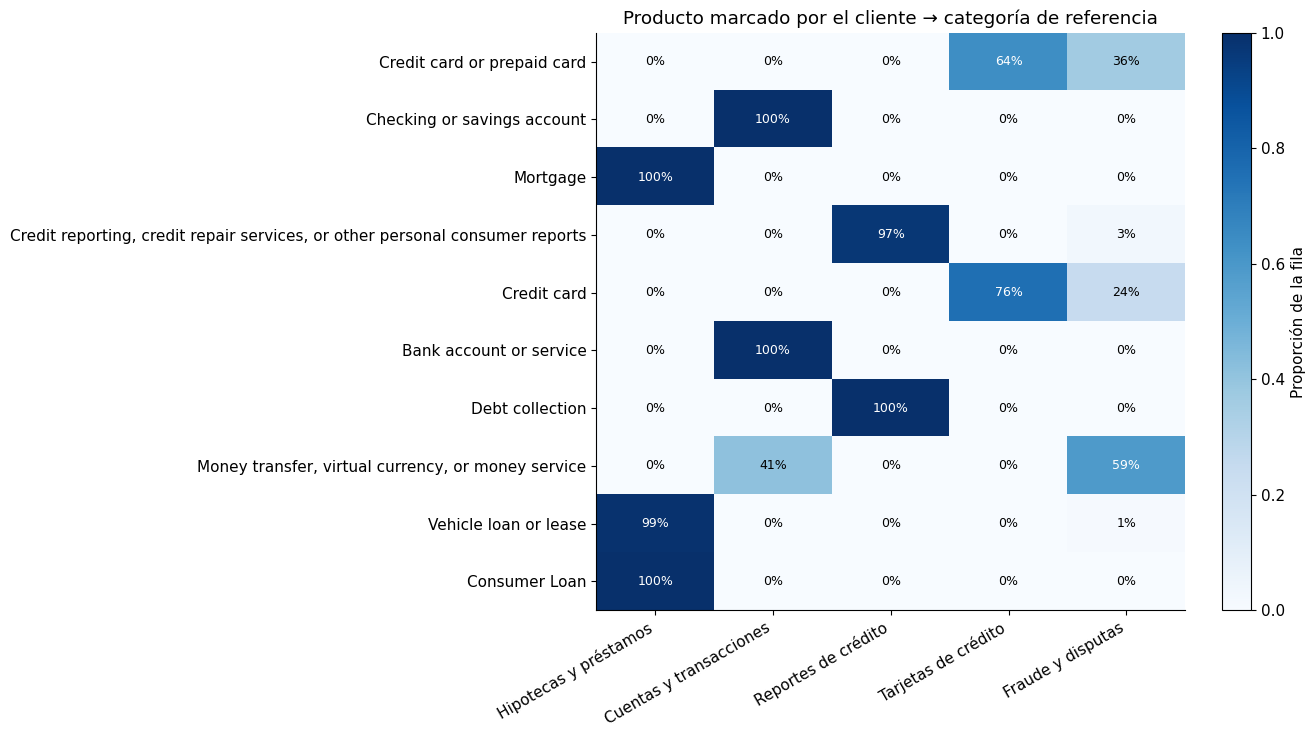

In [10]:
# ¿A qué categoría va cada producto? (cada fila suma 100 %)
producto_vs_categoria = (pd.crosstab(quejas.producto, quejas.categoria_ref, normalize="index")
                         .reindex(columns=range(len(CATEGORIAS)), fill_value=0)
                         .loc[productos_top.index])
dibujar_heatmap(producto_vs_categoria.values, productos_top.index, CATEGORIAS,
                "Producto marcado por el cliente → categoría de referencia", "Proporción de la fila")
plt.show()

👀 **Qué observar:** la mayoría de productos va a una sola categoría (celda oscura). Pero casi todos tienen una parte
en **Fraude y disputas**: el fraude **atraviesa** productos. Será la categoría más difícil de separar.

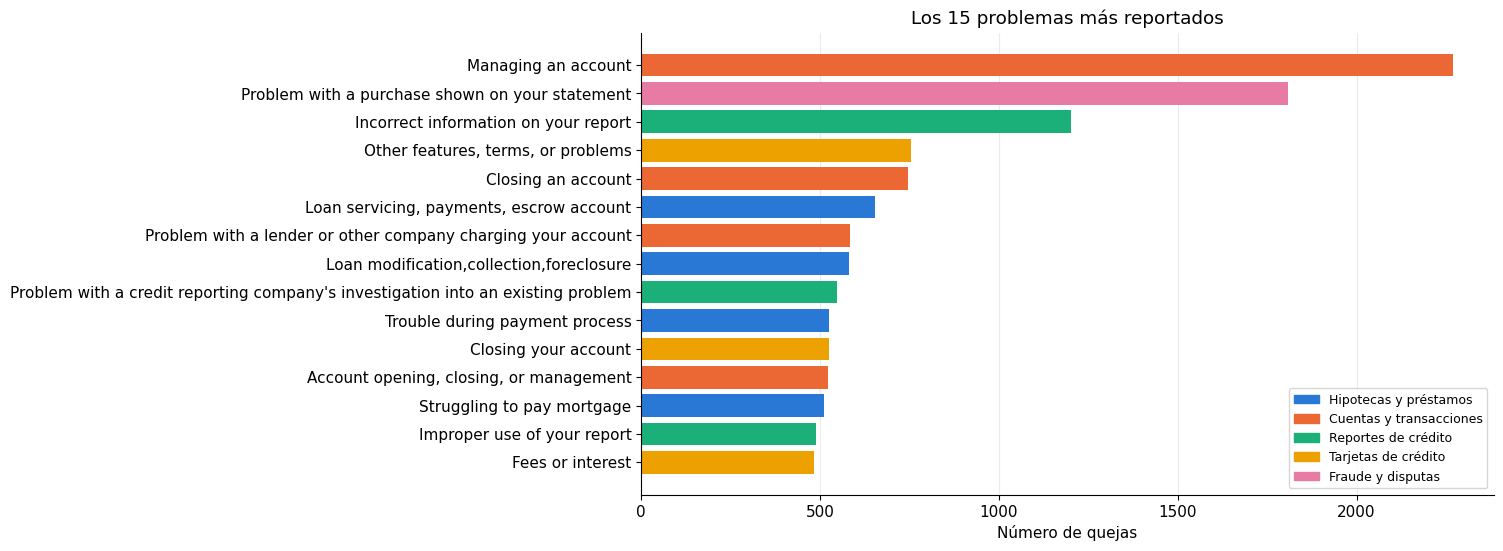

In [11]:
# Los 15 problemas más reportados, coloreados por su categoría más común
problemas_top = quejas.problema.value_counts().head(15)
categoria_del_problema = quejas.groupby("problema").categoria_ref.agg(lambda s: s.mode()[0])

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(problemas_top.index, problemas_top.values,
        color=[COLORES[categoria_del_problema[p]] for p in problemas_top.index])
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("Número de quejas")
ax.set_title("Los 15 problemas más reportados")
ax.legend(handles=[Patch(color=COLORES[i], label=CATEGORIAS[i]) for i in range(len(CATEGORIAS))],
          loc="lower right", fontsize=9)
plt.show()

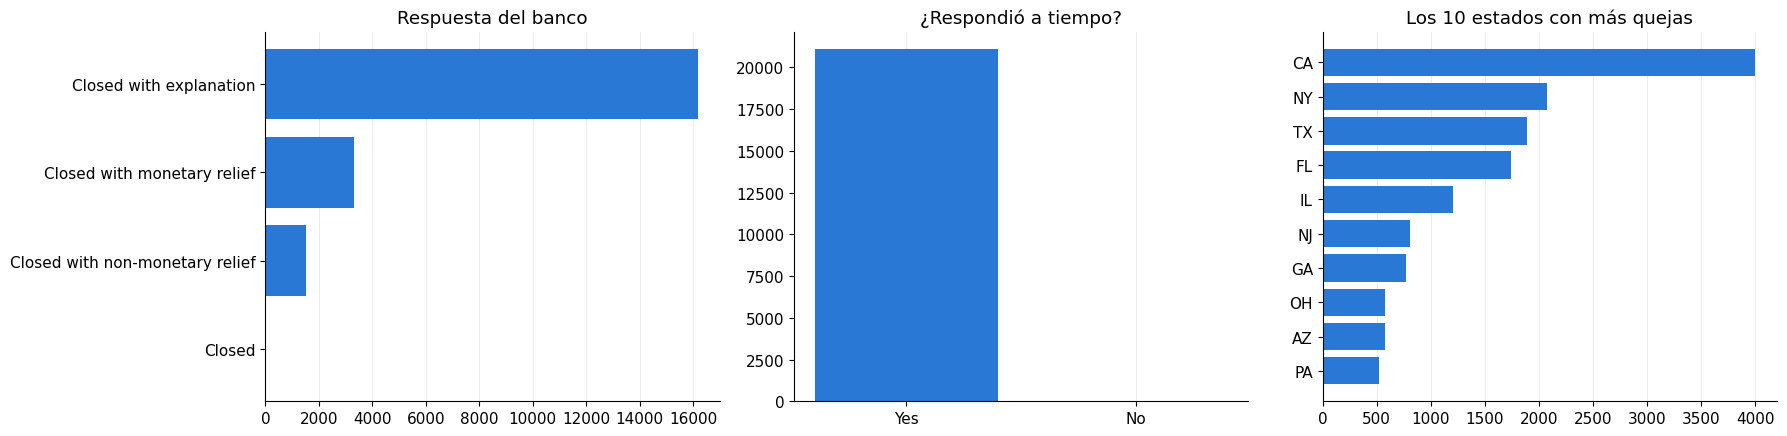

Quejas de poblaciones protegidas:
etiquetas
Older American                   8.8%
Servicemember                    7.7%
Older American, Servicemember    1.6%


In [12]:
# Contexto de operación: cómo responde el banco, si responde a tiempo y de dónde vienen las quejas
fig, ejes = plt.subplots(1, 3, figsize=(18, 4.5))

respuesta = quejas.respuesta.value_counts()
ejes[0].barh(respuesta.index, respuesta.values, color=AZUL)
ejes[0].invert_yaxis(); ejes[0].set_title("Respuesta del banco")

a_tiempo = quejas.a_tiempo.value_counts()
ejes[1].bar(a_tiempo.index, a_tiempo.values, color=[AZUL, GRIS][:len(a_tiempo)])
ejes[1].set_title("¿Respondió a tiempo?")

estados = quejas.estado.value_counts().head(10)
ejes[2].barh(estados.index, estados.values, color=AZUL)
ejes[2].invert_yaxis(); ejes[2].set_title("Los 10 estados con más quejas")

for ax in ejes:
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print("Quejas de poblaciones protegidas:")
print((quejas.etiquetas.value_counts() / len(quejas)).map("{:.1%}".format).to_string())

👀 **Qué observar:** casi todas las quejas se responden a tiempo y la mayoría se cierra "con explicación". El
problema del banco no es *si* responde, sino **cuánto tarda en llegar al equipo correcto**. Ahí es donde un modelo
aporta valor.

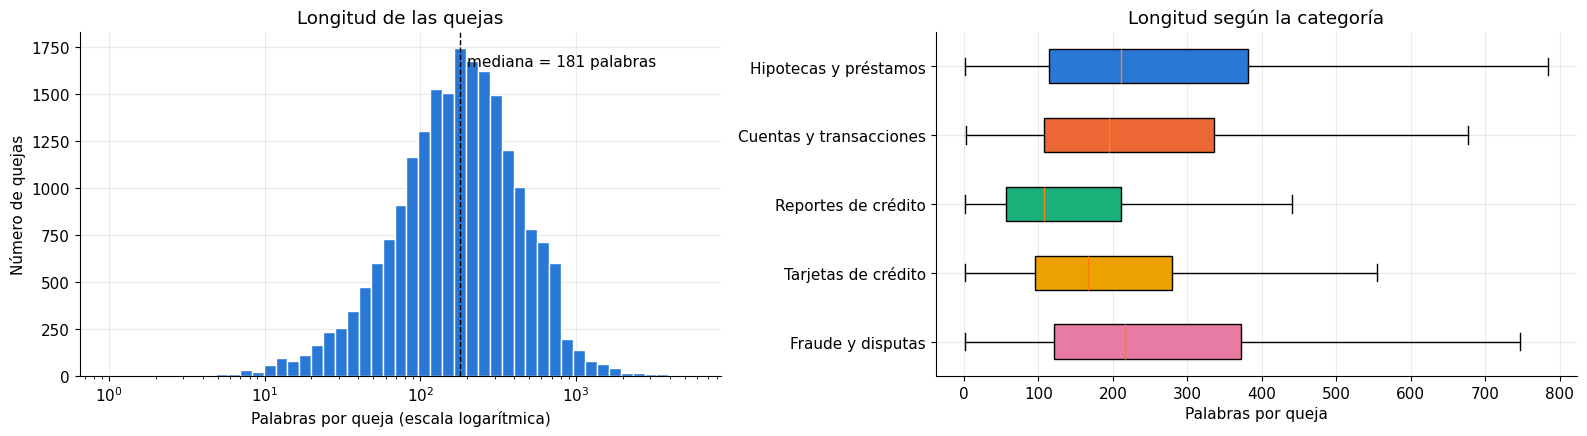

In [13]:
# ¿Qué tan largas son las quejas? ¿Depende de la categoría?
quejas["num_palabras"] = quejas.texto_original.str.split().str.len()

fig, (ax_hist, ax_caja) = plt.subplots(1, 2, figsize=(16, 4.5))

# Histograma en escala logarítmica: muestra bien tanto las quejas cortas como las muy largas
bins = np.logspace(0, np.log10(quejas.num_palabras.max()), 50)
ax_hist.hist(quejas.num_palabras, bins=bins, color=AZUL, edgecolor="white")
ax_hist.set_xscale("log")
mediana = quejas.num_palabras.median()
ax_hist.axvline(mediana, color="black", linestyle="--", linewidth=1)
ax_hist.text(mediana * 1.1, ax_hist.get_ylim()[1] * 0.9, f"mediana = {mediana:.0f} palabras")
ax_hist.set_xlabel("Palabras por queja (escala logarítmica)")
ax_hist.set_ylabel("Número de quejas")
ax_hist.set_title("Longitud de las quejas")

# Diagrama de caja por categoría (sin puntos atípicos, para ver mejor las cajas)
grupos = [quejas.num_palabras[quejas.categoria_ref == i] for i in range(len(CATEGORIAS))]
cajas = ax_caja.boxplot(grupos, vert=False, showfliers=False, patch_artist=True)
ax_caja.set_yticks(range(1, len(CATEGORIAS) + 1), CATEGORIAS)
for caja, color in zip(cajas["boxes"], COLORES):
    caja.set_facecolor(color)
ax_caja.invert_yaxis()
ax_caja.set_xlabel("Palabras por queja")
ax_caja.set_title("Longitud según la categoría")
plt.tight_layout()
plt.show()

👀 **Qué observar:** la mayoría de quejas tiene entre 100 y 300 palabras, pero algunas pasan de 5.000. Las de
hipotecas y de fraude tienden a ser más largas: son historias con más pasos (solicitudes, documentos, reclamos). El modelo de
Hugging Face del paso 7 tiene un límite de longitud, así que allí las recortaremos.

### Leer antes de graficar

Los gráficos resumen, pero **leer ejemplos reales** evita conclusiones equivocadas. Una queja corta de cada categoría:

In [14]:
for numero, categoria in enumerate(CATEGORIAS):
    ejemplo = quejas[(quejas.categoria_ref == numero) & quejas.num_palabras.between(40, 90)].iloc[0]
    print(f"■ {categoria}  |  producto: {ejemplo.producto}  |  problema: {ejemplo.problema}")
    print(f"  {ejemplo.texto_original[:400]}\n")

■ Hipotecas y préstamos  |  producto: Mortgage  |  problema: Struggling to pay mortgage
  I have been trying to do a loan modification with Chase and all they do is give me the runaround I'm 72 mo behind they dont let me make payments I have aens all doc in but always asking more

■ Cuentas y transacciones  |  producto: Checking or savings account  |  problema: Opening an account
  I opened an account with chase bank on XXXX and used a code for XXXX bonus. I called to follow up on XX/XX/XXXX about the terms and was told everything was on the account and once I made XXXX direct deposit the bonus would be paid out in 10 days. As of XXXX I had made the required deposits and was told my account never had the coupon code applied and it was past the 21 days to do so, so no bonus w

■ Reportes de crédito  |  producto: Credit reporting, credit repair services, or other personal consumer reports  |  problema: Improper use of your report
  I have contacted both Chase Bank and XXXX XXXX about cre

✅ **Punto de control:** ya sabes qué datos tienes, por qué falta el texto, qué sesgos tiene la muestra y de qué
tratan las quejas.

## 🧹 Paso 2: Limpiar el texto

### ¿Por qué limpiar?

Para una computadora, `"Card"`, `"card"` y `"card!"` son tres cadenas distintas. **Normalizar** es eliminar esas
diferencias que no aportan significado. Así el vocabulario se reduce y las palabras importantes se repiten más.

Para esto usamos **expresiones regulares** (*regex*), patrones que describen texto:

| Paso | Patrón | Ejemplo |
| --- | --- | --- |
| Minúsculas | — | `Chase` → `chase` |
| Quitar texto entre corchetes | `\[.*?\]` | `[redacted]` → ` ` |
| Quitar puntuación | `[^\w\s]` | `twice!!` → `twice` |
| Quitar palabras con números | `\b\w*\d\w*\b` | `$25.00`, `1234abc` → ` ` |
| Quitar máscaras de datos personales | `\bx{2,}\b` | `XX/XX/XXXX` → ` ` |
| Dejar un solo espacio | `\s+` | `a    b` → `a b` |

> 🔒 **Datos personales:** el regulador reemplaza fechas, nombres y cuentas por `XXXX`. Esas máscaras no dicen nada
> del tema de la queja, pero aparecen en casi todas. Si no las quitamos, `xxxx` sería la "palabra" más común.
>
> 💡 El `?` en `\[.*?\]` importa: sin él, `.*` es "codicioso" y borraría todo lo que hay entre el **primer** `[` y el
> **último** `]` de la queja.

In [15]:
def limpiar_texto(textos):
    # Recibe una columna de pandas con textos y la devuelve normalizada
    return (
        textos.str.lower()                                        # todo en minúsculas
        .str.replace(r"\[.*?\]", " ", regex=True)                 # texto entre corchetes
        .str.replace(r"[^\w\s]", " ", regex=True)                 # puntuación
        .str.replace(r"\b\w*\d\w*\b", " ", regex=True)            # palabras con números
        .str.replace(r"\bx{2,}\b", " ", regex=True)               # máscaras XXXX
        .str.replace(r"\s+", " ", regex=True)                     # espacios repetidos
        .str.strip()                                              # espacios al inicio y al final
    )


# Probemos con una frase inventada que tiene de todo
frase = pd.Series(["On XX/XX/XXXX I was charged $25.00 [redacted] twice by Chase!! Account 1234abc"])
print("Antes:  ", frase[0])
print("Después:", limpiar_texto(frase)[0])

Antes:   On XX/XX/XXXX I was charged $25.00 [redacted] twice by Chase!! Account 1234abc
Después: on i was charged twice by chase account


In [16]:
# Ahora limpiamos todas las quejas y descartamos las que quedaron vacías
quejas["texto_limpio"] = limpiar_texto(quejas.texto_original)
quejas = quejas[quejas.texto_limpio != ""].reset_index(drop=True)

quejas[["texto_original", "texto_limpio"]].head(3)

,texto_original,texto_limpio
0,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent ...,good morning my name is and i appreciate it if you could help me put a stop to chase bank cardmember services in i wrote to chase asking for debt verification and what they sent me a statement whi...
1,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to u...,i upgraded my card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account cha...
2,"Chase Card was reported on XX/XX/2019. However, fraudulent application have been submitted my identity without my consent to fraudulently obtain services. Do not extend credit without verifying th...",chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of ...


## 🧠 Paso 3: Enseñarle a la computadora a leer

El texto está limpio, pero sigue lleno de palabras que no dicen *de qué* trata la queja (`i`, `the`, `was`…). Vamos
a pasar cada queja por un **pipeline de NLP**, una cadena de pasos en la que cada uno responde una pregunta:

1. **Tokenización: ¿cuáles son las palabras?** Separa el texto en *tokens*:
   `"i was charged twice"` → `["i", "was", "charged", "twice"]`.
2. **Stop words: ¿qué palabras no aportan tema?** Artículos, pronombres y preposiciones (`the`, `i`, `was`, `on`)
   aparecen en *todas* las quejas, así que no ayudan a distinguirlas.
3. **Lematización: ¿cuál es la forma base?** `charged`, `charging` y `charges` → `charge`. A diferencia del
   *stemming*, que corta sufijos a ciegas (`studies` → `studi`), la lematización usa un diccionario y devuelve una
   palabra real (`studies` → `study`).
4. **Etiquetado gramatical (POS): ¿qué función cumple cada palabra?** Un modelo estadístico asigna a cada palabra una
   etiqueta del estándar *Penn Treebank*:

| Etiqueta | Significa | Ejemplo | ¿La usamos para los temas? |
| --- | --- | --- | --- |
| `NN`, `NNS` | Sustantivo | *card*, *payments*, *mortgage* | ✅ dice **de qué** trata la queja |
| `VB`, `VBD`, `VBG`… | Verbo | *call*, *tell*, *charge* | ❌ casi siempre genéricos (*call*, *tell*, *say*) |
| `JJ` | Adjetivo | *late*, *fraudulent* | ❌ |
| `RB` | Adverbio | *never*, *twice* | ❌ |
| `PRP`, `DT`, `IN`… | Pronombre, determinante, preposición | *i*, *the*, *on* | ❌ |

> 🧪 **¿Por qué solo sustantivos?** Probamos varias combinaciones y los temas más limpios salieron usando **solo
> sustantivos**. Coincide con la investigación: Martin y Johnson (2015) mostraron que los temas hechos solo con
> sustantivos son igual de coherentes y mucho más fáciles de leer. Lo comprobarás tú mismo en unas celdas.

5. **N-gramas: ¿qué palabras van juntas?** Un *bigrama* es un par de palabras seguidas, como `credit report` o
   `loan modification`. Tienen un significado que las palabras sueltas pierden. Los agregaremos en el paso 4.

🔬 Veamos los pasos 1 a 4 sobre una sola frase:

In [17]:
# Cargamos spaCy. Desactivamos el análisis sintáctico ("parser") y el de entidades ("ner")
# porque no los necesitamos: así va mucho más rápido.
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Etiquetas POS: miramos las dos primeras letras, así "NNS" cuenta como "NN" y "VBD" como "VB"
SUSTANTIVOS = ("NN",)
PALABRAS_CON_CONTENIDO = ("NN", "JJ", "VB", "RB")   # para comparar


def es_candidata(token):
    # Palabra real (solo letras), que no es stop word y tiene más de 2 letras
    return token.is_alpha and not token.is_stop and len(token.lemma_) > 2


frase = "I called the bank twice because they charged a late fee on my mortgage payment"
pd.DataFrame([
    {"token": t.text, "lema": t.lemma_, "etiqueta POS": t.tag_, "¿stop word?": t.is_stop,
     "¿la usamos?": es_candidata(t) and t.tag_[:2] in SUSTANTIVOS}
    for t in nlp(frase)
])

,token,lema,etiqueta POS,¿stop word?,¿la usamos?
0,I,I,PRP,True,False
1,called,call,VBD,False,False
2,the,the,DT,True,False
3,bank,bank,NN,False,True
4,twice,twice,RB,False,False
5,because,because,IN,True,False
6,they,they,PRP,True,False
7,charged,charge,VBD,False,False
8,a,a,DT,True,False
9,late,late,JJ,False,False


👀 **Qué observar:** de 16 palabras nos quedamos con `bank`, `fee`, `mortgage` y `payment`. Con eso ya sabes de qué
trata la queja; `call` y `twice` no lo dicen.

Ahora analizamos **todas** las quejas. `nlp.pipe` las procesa por lotes y en paralelo, mucho más rápido que una por
una. Guardamos cada lema **con su etiqueta**, para poder comparar después distintos filtros.

⏳ *Tarda unos minutos: buen momento para un café.*

In [18]:
def analizar(textos, procesos=4):
    # Para cada texto, devuelve una lista de pares (lema, etiqueta POS) de las palabras candidatas
    documentos = nlp.pipe(textos, batch_size=256, n_process=procesos)   # varios procesos en paralelo
    return [[(token.lemma_.lower(), token.tag_) for token in doc if es_candidata(token)]
            for doc in documentos]


def unir_lemas(tokens, etiquetas):
    # Une en un texto los lemas cuyas etiquetas empiezan como alguna de `etiquetas`
    return " ".join(lema for lema, etiqueta in tokens if etiqueta[:2] in etiquetas)


def extraer_lemas(textos, procesos=4):
    # Lo que usaremos con quejas nuevas: texto limpio → sustantivos lematizados
    return [unir_lemas(tokens, SUSTANTIVOS) for tokens in analizar(textos, procesos)]


inicio = time.time()
tokens_por_queja = analizar(quejas.texto_limpio)
print(f"Listo en {time.time() - inicio:.0f} segundos")

quejas["lemas_contenido"] = [unir_lemas(t, PALABRAS_CON_CONTENIDO) for t in tokens_por_queja]
quejas["lemas"] = [unir_lemas(t, SUSTANTIVOS) for t in tokens_por_queja]
quejas[["texto_limpio", "lemas"]].head(3)

Listo en 160 segundos


,texto_limpio,lemas
0,good morning my name is and i appreciate it if you could help me put a stop to chase bank cardmember services in i wrote to chase asking for debt verification and what they sent me a statement whi...,morning stop bank cardmember service debt verification statement bank debt mail month debt right information consumer chase account thank advance help
1,i upgraded my card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account cha...,card agent anniversary date agent information order account anniversary date consent recording agent
2,chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of ...,chase card application identity consent service credit identity applicant


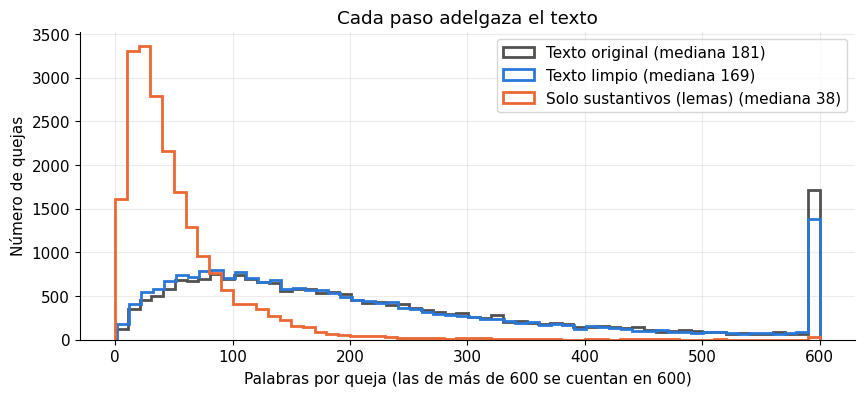

In [19]:
# ¿Cuánto "adelgaza" cada paso el texto?
longitudes = {
    "Texto original": quejas.texto_original.str.split().str.len(),
    "Texto limpio": quejas.texto_limpio.str.split().str.len(),
    "Solo sustantivos (lemas)": quejas.lemas.str.split().str.len(),
}
fig, ax = plt.subplots()
for (nombre, serie), color in zip(longitudes.items(), ["#52514e", AZUL, COLORES[1]]):
    ax.hist(serie.clip(upper=600), bins=60, histtype="step", linewidth=2, color=color,
            label=f"{nombre} (mediana {serie.median():.0f})")
ax.set_xlabel("Palabras por queja (las de más de 600 se cuentan en 600)")
ax.set_ylabel("Número de quejas")
ax.set_title("Cada paso adelgaza el texto")
ax.legend()
plt.show()

👀 **Qué observar:** nos quedamos con cerca de una de cada cinco palabras, pero la queja sigue diciendo *de qué*
trata.

### Palabras que están en todas partes

¿Qué pasa si una palabra aparece en casi **todas** las quejas? No sirve para distinguirlas. Midamos en qué
**porcentaje de quejas** aparece cada lema. A esto se le llama **frecuencia documental**.

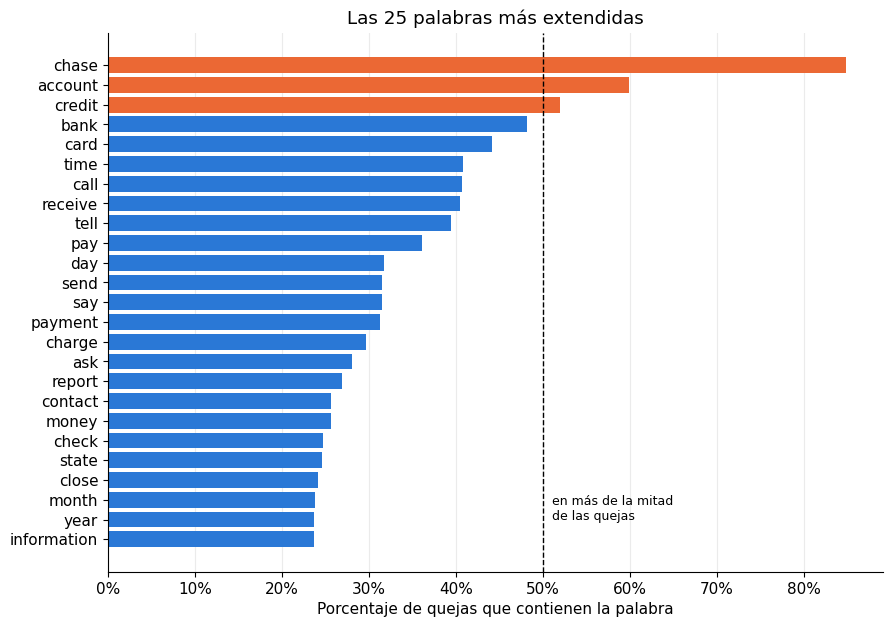

In [20]:
# binary=True: solo nos importa si la palabra aparece en la queja, no cuántas veces
presencia = CountVectorizer(binary=True, min_df=5)
X_presencia = presencia.fit_transform(quejas.lemas_contenido)
porcentaje = pd.Series(np.asarray(X_presencia.mean(axis=0)).ravel(), index=presencia.get_feature_names_out())
top_25 = porcentaje.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_25.index[::-1], top_25.values[::-1],
        color=[COLORES[1] if v > 0.5 else AZUL for v in top_25.values[::-1]])
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.text(0.51, 1, "en más de la mitad\nde las quejas", fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
ax.set_xlabel("Porcentaje de quejas que contienen la palabra")
ax.set_title("Las 25 palabras más extendidas")
plt.show()

👀 **Qué observar:** `chase`, `bank` y `account` aparecen en más de la mitad de las quejas. Son como *stop words*
**del dominio**: vacías *para este problema*, aunque no para el idioma. En el paso 4 las filtraremos con `max_df=0.5`
("ignora lo que esté en más del 50 % de las quejas").

### Comprobación: ¿solo sustantivos?

In [21]:
def top_palabras(textos, cuantas=12):
    return list(pd.Series(" ".join(textos).split()).value_counts().head(cuantas).index)


pd.DataFrame({
    "Sustantivos, verbos, adjetivos y adverbios": top_palabras(quejas.lemas_contenido),
    "Solo sustantivos": top_palabras(quejas.lemas),
}, index=range(1, 13))

,"Sustantivos, verbos, adjetivos y adverbios",Solo sustantivos
1,chase,chase
2,account,account
3,credit,credit
4,card,card
5,bank,bank
6,payment,payment
7,tell,time
8,charge,day
9,receive,charge
10,call,money


👀 **Qué observar:** con verbos aparecen `tell`, `call`, `say`, `receive`: todas las quejas "llaman", "dicen" y
"reciben". Con solo sustantivos, la lista habla de productos: `card`, `payment`, `loan`, `credit`.

✅ **Punto de control:** cada queja es ahora una lista corta de sustantivos con significado.

## 🔢 Paso 4: Convertir palabras en números

### Bag of Words: la bolsa de palabras

Cada queja se convierte en un vector con **una posición por cada palabra del vocabulario**. El valor es cuántas
veces aparece esa palabra en la queja. El orden de las palabras se pierde: es como meterlas todas en una bolsa.
El corpus completo queda como una matriz **quejas × vocabulario**, casi toda llena de ceros (una *matriz dispersa*).

### TF-IDF: premiar lo que distingue

Contar no basta: una palabra que aparece en *todas* las quejas no ayuda a separarlas. **TF-IDF** premia las palabras
frecuentes *en una queja* pero raras *en el resto*:

$$\text{tfidf}(t, d) = \underbrace{\text{tf}(t, d)}_{\text{veces en la queja}} \times
\underbrace{\text{idf}(t)}_{\text{qué tan rara es}}, \qquad
\text{idf}(t) = \ln\frac{1 + N}{1 + \text{df}(t)} + 1$$

- $N$ es el número de quejas y $\text{df}(t)$ el número de quejas que contienen el término $t$.
- Si $t$ está en todas las quejas, $\text{idf}(t) = 1$ (el mínimo). Si está en pocas, el idf es alto.
- Al final, cada vector se normaliza a longitud 1, para que las quejas largas no pesen más que las cortas.

🔬 Veámoslo con tres "quejas" de juguete:

In [22]:
quejas_juguete = ["card charged twice", "mortgage payment late", "fraud charge card"]

# Bag of Words: conteos
bolsa = CountVectorizer().fit(quejas_juguete)
print("Bag of Words (cuántas veces aparece cada palabra):")
display(pd.DataFrame(bolsa.transform(quejas_juguete).toarray(),
                     columns=bolsa.get_feature_names_out(), index=quejas_juguete))

# TF-IDF: pesos
tfidf_juguete = TfidfVectorizer().fit(quejas_juguete)
print("TF-IDF (qué tan distintiva es cada palabra en cada queja):")
display(pd.DataFrame(tfidf_juguete.transform(quejas_juguete).toarray(),
                     columns=tfidf_juguete.get_feature_names_out(), index=quejas_juguete).round(2))

Bag of Words (cuántas veces aparece cada palabra):


,card,charge,charged,fraud,late,mortgage,payment,twice
card charged twice,1,0,1,0,0,0,0,1
mortgage payment late,0,0,0,0,1,1,1,0
fraud charge card,1,1,0,1,0,0,0,0


TF-IDF (qué tan distintiva es cada palabra en cada queja):


,card,charge,charged,fraud,late,mortgage,payment,twice
card charged twice,0.47,0.00,0.62,0.00,0.00,0.00,0.00,0.62
mortgage payment late,0.00,0.00,0.00,0.00,0.58,0.58,0.58,0.00
fraud charge card,0.47,0.62,0.00,0.62,0.00,0.00,0.00,0.00


👀 **Qué observar:** `card` aparece en dos quejas, así que pesa menos que `twice` o `mortgage`, que solo aparecen en
una. TF-IDF resalta lo que hace **única** a cada queja.

### El vocabulario de cada área

Antes de vectorizar todo, exploremos qué **bigramas** (pares de palabras) usa cada categoría.

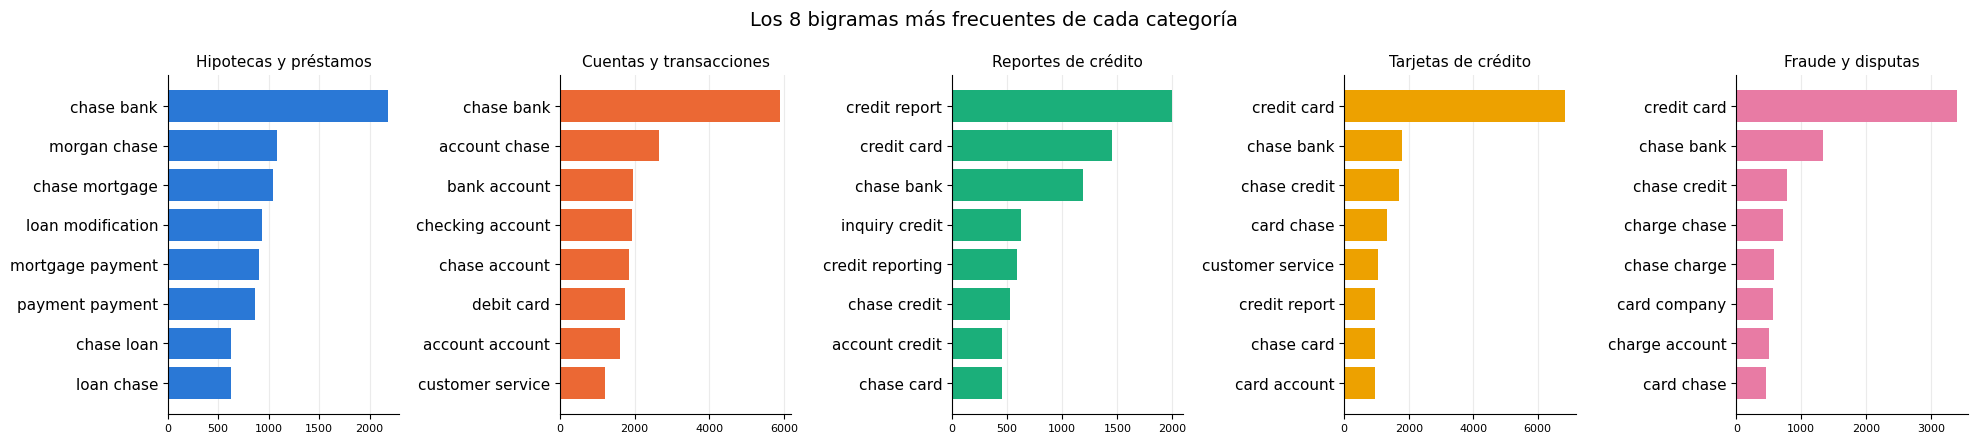

In [23]:
fig, ejes = plt.subplots(1, len(CATEGORIAS), figsize=(20, 4.5))
for numero, (categoria, ax) in enumerate(zip(CATEGORIAS, ejes)):
    textos = quejas.lemas[quejas.categoria_ref == numero]
    bigramas = CountVectorizer(ngram_range=(2, 2), min_df=5).fit(textos)
    frecuencia = pd.Series(np.asarray(bigramas.transform(textos).sum(axis=0)).ravel(),
                           index=bigramas.get_feature_names_out()).nlargest(8)
    ax.barh(frecuencia.index[::-1], frecuencia.values[::-1], color=COLORES[numero])
    ax.set_title(categoria, fontsize=11)
    ax.grid(axis="y", visible=False); ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Los 8 bigramas más frecuentes de cada categoría", fontsize=14)
plt.tight_layout()
plt.show()

👀 **Qué observar:** cada área tiene su propio vocabulario: `loan modification` en hipotecas, `credit report` en
reportes, `card account` en tarjetas. Esa es la señal que los modelos van a aprovechar.

### Frecuente no es lo mismo que distintivo

Una palabra puede ser muy frecuente en una categoría… y en todas las demás. Comparemos las palabras **más
frecuentes** de cada categoría con las **más distintivas**: las que tienen más peso TF-IDF en esa categoría que en
el promedio.

In [24]:
tfidf_exploracion = TfidfVectorizer(min_df=5, max_df=0.5)
X_exploracion = tfidf_exploracion.fit_transform(quejas.lemas)
terminos = tfidf_exploracion.get_feature_names_out()
promedio_general = np.asarray(X_exploracion.mean(axis=0)).ravel()

filas = {}
for numero, categoria in enumerate(CATEGORIAS):
    en_categoria = (quejas.categoria_ref == numero).values
    promedio_categoria = np.asarray(X_exploracion[en_categoria].mean(axis=0)).ravel()
    distintivas = terminos[np.argsort(promedio_categoria - promedio_general)[::-1][:6]]
    filas[categoria] = {"Más frecuentes": ", ".join(top_palabras(quejas.lemas[en_categoria], 6)),
                        "Más distintivas (TF-IDF)": ", ".join(distintivas)}
pd.DataFrame(filas).T

,Más frecuentes,Más distintivas (TF-IDF)
Hipotecas y préstamos,"chase, payment, loan, mortgage, bank, time","loan, mortgage, payment, home, modification, property"
Cuentas y transacciones,"account, chase, bank, check, money, day","check, bank, money, fund, deposit, transaction"
Reportes de crédito,"credit, chase, account, report, card, payment","inquiry, report, debt, jpmcb, reporting, company"
Tarjetas de crédito,"chase, card, credit, account, payment, balance","card, balance, interest, point, limit, offer"
Fraude y disputas,"chase, card, charge, credit, account, dispute","charge, dispute, merchant, card, fraud, transaction"


👀 **Qué observar:** `payment` o `card` son frecuentes en varias categorías. Las distintivas son más específicas:
por ejemplo `inquiry` en reportes o `claim` en fraude. Esto anticipa lo que hará LDA en el paso 5.

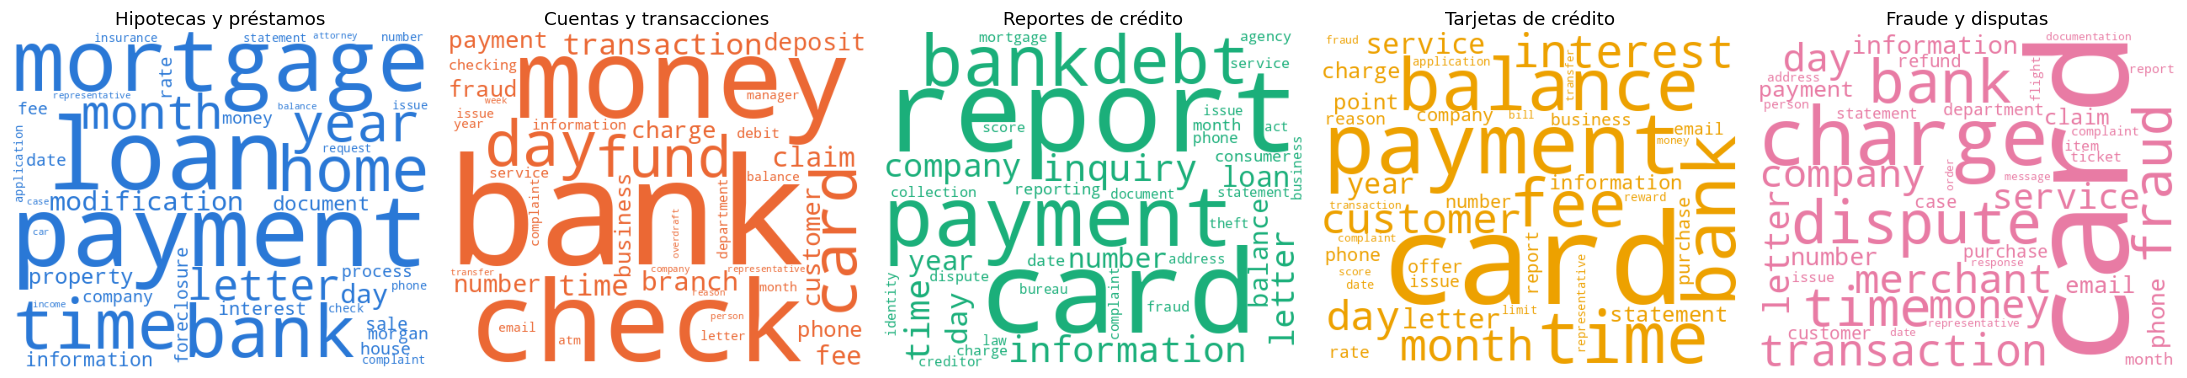

In [25]:
# Nubes de palabras: el tamaño de cada palabra es su frecuencia en la categoría
try:
    from wordcloud import WordCloud
except ImportError:
    WordCloud = None
    print("La librería wordcloud no está instalada: esta celda es opcional.")

# Quitamos las palabras que están en más de la mitad de las quejas (chase, account…): taparían todo lo demás
GENERICAS = set(porcentaje[porcentaje > 0.5].index)

if WordCloud is not None:
    fig, ejes = plt.subplots(1, len(CATEGORIAS), figsize=(22, 4))
    for numero, (categoria, ax) in enumerate(zip(CATEGORIAS, ejes)):
        palabras = [p for p in " ".join(quejas.lemas[quejas.categoria_ref == numero]).split() if p not in GENERICAS]
        frecuencias = pd.Series(palabras).value_counts()
        nube = WordCloud(width=500, height=400, background_color="white", max_words=40,
                         color_func=lambda *args, color=COLORES[numero], **kwargs: color)
        # generate_from_frequencies usa TODO el corpus de la categoría
        ax.imshow(nube.generate_from_frequencies(frecuencias.to_dict()))
        ax.set_title(categoria)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### ⚠️ Separar los datos ANTES de aprender: la fuga de datos

Vamos a entrenar modelos, y después a evaluarlos con quejas que **nunca vieron**. Para que esa evaluación sea honesta,
**todo** lo que se aprende de los datos se aprende solo con el conjunto de entrenamiento: el vocabulario, los pesos
IDF, los temas de LDA y el clasificador.

Si ajustáramos el vocabulario con todas las quejas, el modelo ya habría "visto" las palabras de las quejas de prueba.
Eso se llama **fuga de datos** (*data leakage*) y hace que los resultados se vean mejores de lo que son. Es un error
muy común.

> ℹ️ El análisis exploratorio de arriba sí usó todas las quejas: explorar no es entrenar. Lo que importa es que
> ninguna decisión del **modelo** se aprenda de las quejas de prueba.

Por eso separamos **ahora**: 70 % para entrenar y 30 % para probar.

In [26]:
idx_entrenamiento, idx_prueba = train_test_split(quejas.index, test_size=0.3, random_state=42)
print(f"Entrenamiento: {len(idx_entrenamiento):,} quejas | Prueba: {len(idx_prueba):,} quejas")

Entrenamiento: 14,750 quejas | Prueba: 6,322 quejas


### Vectorizar las quejas de entrenamiento

| Parámetro | Valor | Por qué |
| --- | --- | --- |
| `ngram_range` | `(1, 2)` | Palabras sueltas **y** bigramas |
| `min_df` | `5` | Ignorar términos en menos de 5 quejas (errores de tipeo, nombres raros) |
| `max_df` | `0.5` | Ignorar términos en más del 50 % de las quejas (`chase`, `account`…) |
| `max_features` | `20000` | Quedarnos con los 20.000 términos más frecuentes |

In [27]:
# Bag of Words con palabras y bigramas. LDA trabaja con estos conteos.
vectorizador = CountVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.5, max_features=20000)
X_entrenamiento = vectorizador.fit_transform(quejas.lemas[idx_entrenamiento])   # fit: SOLO entrenamiento
X_prueba = vectorizador.transform(quejas.lemas[idx_prueba])                     # transform: usa lo aprendido
vocabulario = vectorizador.get_feature_names_out()

num_quejas, num_terminos = X_entrenamiento.shape
print(f"Matriz de entrenamiento: {num_quejas:,} quejas × {num_terminos:,} términos")
print(f"Solo el {X_entrenamiento.nnz / (num_quejas * num_terminos):.2%} de las celdas tiene un valor distinto de cero")
print("¿Quedó 'chase' en el vocabulario?", "chase" in set(vocabulario))

Matriz de entrenamiento: 14,750 quejas × 20,000 términos
Solo el 0.26% de las celdas tiene un valor distinto de cero
¿Quedó 'chase' en el vocabulario? False


✅ **Punto de control:** cada queja es ahora un vector de números, y aprendimos el vocabulario sin mirar las quejas
de prueba.

## 🧭 Paso 5: Descubrir los temas escondidos

Recuerda el problema: **no tenemos etiquetas confiables**. ¿Podemos encontrar los temas de las quejas sin que
nadie nos diga cuáles son? Para eso existe el **modelado de temas**, una técnica **no supervisada**: busca grupos de
palabras que suelen aparecer juntas.

### Cómo "piensa" LDA

**LDA (Latent Dirichlet Allocation)** imagina que cada queja se escribió así:

1. El cliente elige una mezcla de temas $\theta_d \sim \text{Dirichlet}(\alpha)$. Por ejemplo: 70 % tarjetas y
   30 % fraude.
2. Para cada palabra que escribe:
   - elige un tema al azar según esa mezcla, $z \sim \text{Multinomial}(\theta_d)$;
   - elige una palabra típica de ese tema, $w \sim \text{Multinomial}(\varphi_z)$. Cada tema $\varphi_k$ es una
     distribución sobre el vocabulario: el tema "tarjetas" tiene alta probabilidad para `card`, `fee`, `balance`.

LDA recorre ese camino **al revés**: mira las palabras observadas y **deduce** $\theta_d$ (qué temas tiene cada
queja) y $\varphi_k$ (qué palabras definen cada tema).

### Las perillas de LDA

| Parámetro | Valor | Qué significa |
| --- | --- | --- |
| `n_components` | 5 | Número de temas: uno por cada área del banco |
| `doc_topic_prior` ($\alpha$) | 0.05 | Un $\alpha$ pequeño dice "cada queja trata **sobre todo de un tema**". Es lo que esperamos al enrutar |
| `learning_method` | `"batch"` | Usa todas las quejas en cada iteración: más lento, pero más preciso |
| `max_iter` | 20 | Iteraciones de aprendizaje |

- LDA usa **conteos** (Bag of Words), no TF-IDF, porque su modelo cuenta palabras.
- LDA **no pone nombres** a los temas. Solo entrega listas de palabras, y un humano debe interpretarlas.

### ⚠️ LDA depende del azar

LDA empieza desde un punto aleatorio (la **semilla**, `random_state`), y distintas semillas pueden dar temas muy
distintos. ¿Cómo elegimos una **sin mirar las etiquetas**? Con la **perplejidad**: mide qué tan "sorprendido" queda el
modelo con los textos. **Menor perplejidad = el modelo explica mejor las quejas.** Entrenamos 10 semillas y nos
quedamos con la de menor perplejidad.

⏳ *Tarda unos 5 minutos.*

In [28]:
NUM_TEMAS = 5
SEMILLAS = range(10)

modelos, perplejidades = [], []
inicio = time.time()
for semilla in SEMILLAS:
    modelo = LatentDirichletAllocation(
        n_components=NUM_TEMAS,
        doc_topic_prior=0.05,       # α pequeño: cada queja trata sobre todo de un tema
        learning_method="batch",
        max_iter=20,
        random_state=semilla,
        n_jobs=-1,                  # usa todos los núcleos del procesador
    )
    modelo.fit(X_entrenamiento)
    modelos.append(modelo)
    perplejidades.append(modelo.perplexity(X_entrenamiento))
    print(f"Semilla {semilla}: perplejidad {perplejidades[-1]:,.0f}")

mejor_semilla = int(np.argmin(perplejidades))
lda = modelos[mejor_semilla]
print(f"\n{time.time() - inicio:.0f} s. Nos quedamos con la semilla {mejor_semilla}.")

Semilla 0: perplejidad 1,915
Semilla 1: perplejidad 1,938
Semilla 2: perplejidad 1,919
Semilla 3: perplejidad 1,990
Semilla 4: perplejidad 1,873
Semilla 5: perplejidad 1,959
Semilla 6: perplejidad 1,911
Semilla 7: perplejidad 1,902
Semilla 8: perplejidad 1,902
Semilla 9: perplejidad 1,913

406 s. Nos quedamos con la semilla 4.


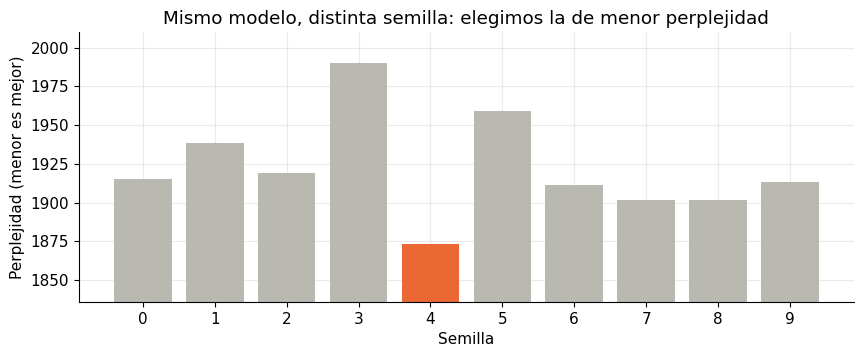

In [29]:
fig, ax = plt.subplots(figsize=(10, 3.5))
colores_barras = [COLORES[1] if s == mejor_semilla else GRIS for s in SEMILLAS]
ax.bar([str(s) for s in SEMILLAS], perplejidades, color=colores_barras)
ax.set_ylim(min(perplejidades) * 0.98, max(perplejidades) * 1.01)   # zoom para ver las diferencias
ax.set_xlabel("Semilla")
ax.set_ylabel("Perplejidad (menor es mejor)")
ax.set_title("Mismo modelo, distinta semilla: elegimos la de menor perplejidad")
plt.show()

👀 **Qué observar:** las diferencias parecen pequeñas, pero los temas pueden cambiar mucho entre semillas. La
perplejidad **no usa las etiquetas**, así que elegir con ella es honesto: haríamos lo mismo en un banco que no tuviera
ninguna etiqueta.

In [30]:
# mezcla_de_temas tiene una fila por queja y una columna por tema: es θ.
# Cada fila suma 1, por ejemplo [0.90, 0.02, 0.03, 0.03, 0.02].
mezcla_de_temas = lda.transform(X_entrenamiento)
temas_entrenamiento = mezcla_de_temas.argmax(axis=1)            # el tema dominante es la etiqueta
temas_prueba = lda.transform(X_prueba).argmax(axis=1)           # para evaluar el clasificador en el paso 6


def palabras_clave(tema, cuantas=10):
    # Las palabras con más peso en un tema (su φ)
    pesos = lda.components_[tema]
    return list(vocabulario[pesos.argsort()[::-1][:cuantas]])


# Nombramos cada tema con la categoría de referencia más común entre sus quejas.
# Es una sugerencia: compárala con las palabras clave y corrígela si no estás de acuerdo.
categorias_entrenamiento = quejas.categoria_ref[idx_entrenamiento].values
quejas_por_tema_y_categoria = (pd.crosstab(temas_entrenamiento, categorias_entrenamiento)
                               .reindex(columns=range(len(CATEGORIAS)), fill_value=0))
TEMA_A_CATEGORIA = quejas_por_tema_y_categoria.idxmax(axis=1).to_dict()

pd.DataFrame({
    "Categoría sugerida": [CATEGORIAS[TEMA_A_CATEGORIA[k]] for k in range(NUM_TEMAS)],
    "Quejas": np.bincount(temas_entrenamiento, minlength=NUM_TEMAS),
    "Palabras clave": [", ".join(palabras_clave(k)) for k in range(NUM_TEMAS)],
}, index=[f"Tema {k}" for k in range(NUM_TEMAS)])

,Categoría sugerida,Quejas,Palabras clave
Tema 0,Cuentas y transacciones,4231,"bank, money, check, chase bank, fund, day, branch, transaction, time, number"
Tema 1,Tarjetas de crédito,1999,"payment, fee, card, balance, credit, interest, month, statement, credit card, time"
Tema 2,Reportes de crédito,2903,"credit, card, credit card, report, credit report, information, letter, inquiry, bank, score"
Tema 3,Fraude y disputas,2467,"charge, card, dispute, credit, time, credit card, transaction, merchant, fraud, service"
Tema 4,Hipotecas y préstamos,3150,"loan, payment, mortgage, time, home, bank, year, letter, property, month"


🕵️ **Tu turno:** lee las palabras clave de cada tema. ¿El nombre sugerido tiene sentido? Si no, corrígelo en una
celda nueva, por ejemplo `TEMA_A_CATEGORIA[2] = 4`. Puede pasar que dos temas terminen en la misma categoría, o que
alguna categoría no tenga tema. Esa es una limitación real de LDA: encuentra lo que **más se repite**, no
necesariamente lo que el negocio necesita.

### 🗺️ El mapa de los temas

Cada queja tiene 5 números (su mezcla de temas), pero no podemos dibujar 5 dimensiones. **t-SNE** es una técnica que
reduce muchas dimensiones a 2 intentando que las quejas **parecidas queden cerca**.

Dos detalles hacen que el mapa muestre islas claras:

1. **Distancia de Hellinger.** Las mezclas de temas son probabilidades: viven en un "triángulo" (un *simplex*) y
   t-SNE las dibuja como una estrella de brazos continuos. La forma correcta de comparar probabilidades es la
   **distancia de Hellinger**, y se consigue con un truco simple: sacar la **raíz cuadrada** de cada mezcla y luego
   usar la distancia normal.
2. **Solo las quejas claras.** Dibujamos las quejas cuyo tema dominante pesa al menos 60 %. Las demás mezclan temas:
   son justo las que, en la vida real, conviene enviar a revisión humana.

> 📏 **Cómo leer un mapa t-SNE:** importan los **grupos**, no las distancias exactas ni los ejes.

Dibujamos el mismo mapa dos veces: a la izquierda coloreado por **tema LDA** (lo que descubrió el modelo) y a la
derecha por **categoría de referencia** (lo que marcó el cliente).

Quejas con un tema claro (≥ 60%): 78%


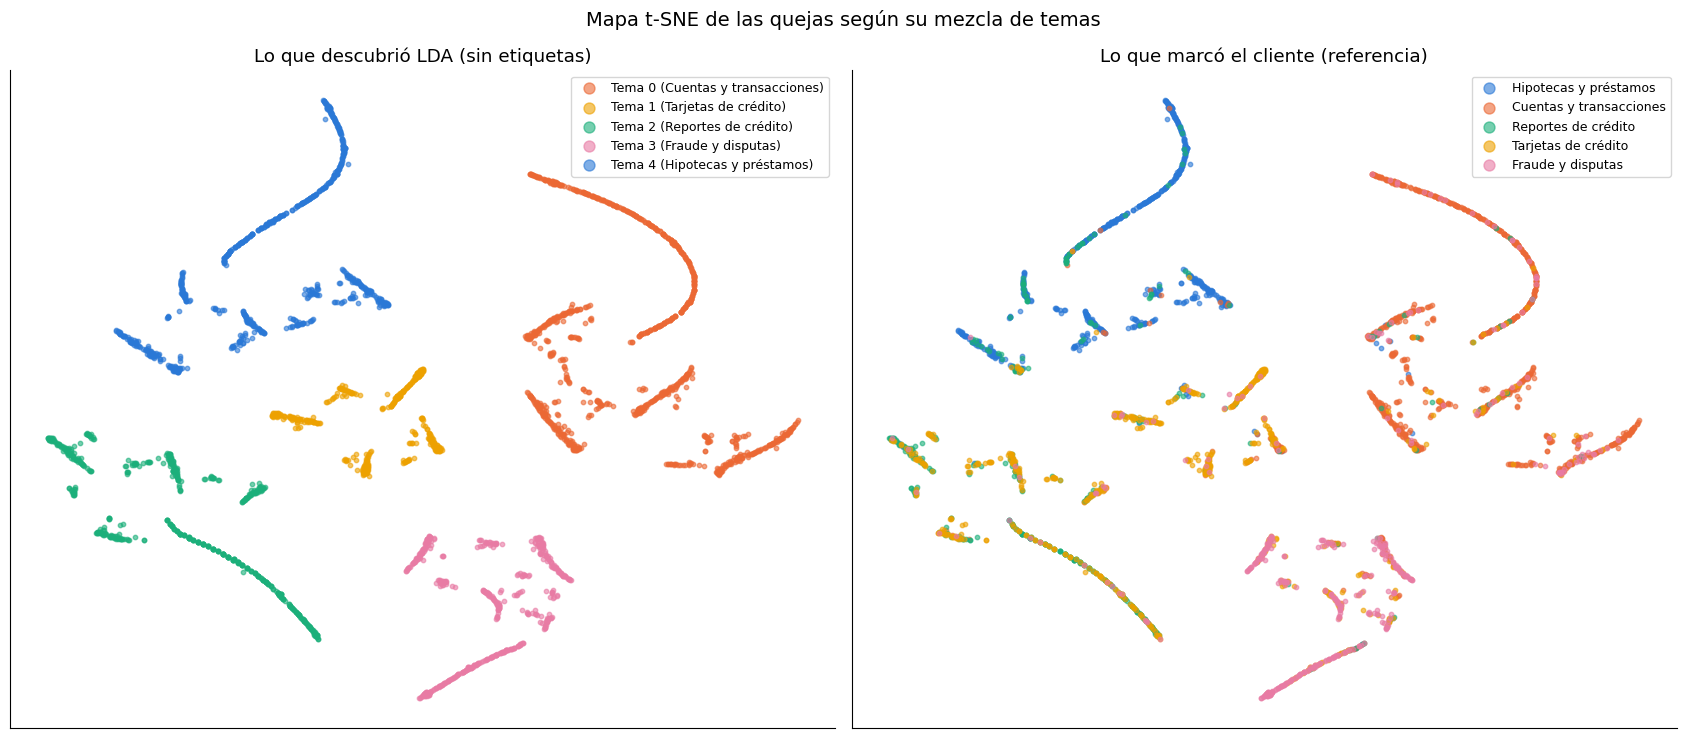

In [31]:
UMBRAL_CLARIDAD = 0.6
claridad = mezcla_de_temas.max(axis=1)                  # peso del tema dominante de cada queja
claras = np.where(claridad >= UMBRAL_CLARIDAD)[0]
print(f"Quejas con un tema claro (≥ {UMBRAL_CLARIDAD:.0%}): {len(claras) / len(claridad):.0%}")

# t-SNE es lento con muchos puntos: usamos una muestra de 3.000 quejas claras
generador = np.random.default_rng(42)
elegidas = generador.choice(claras, size=min(3000, len(claras)), replace=False)

tsne = TSNE(n_components=2, perplexity=40, init="pca", random_state=42)
coordenadas = tsne.fit_transform(np.sqrt(mezcla_de_temas[elegidas]))   # raíz cuadrada = Hellinger

muestra = pd.DataFrame({
    "x": coordenadas[:, 0],
    "y": coordenadas[:, 1],
    "tema": temas_entrenamiento[elegidas],
    "categoria_ref": categorias_entrenamiento[elegidas],
})


def dibujar_mapa(ax, columna_grupo, nombres, colores, marcadores, titulo):
    # Un scatter por grupo, para que cada uno tenga su color, su forma y su entrada en la leyenda
    for grupo, nombre in enumerate(nombres):
        puntos = muestra[muestra[columna_grupo] == grupo]
        ax.scatter(puntos.x, puntos.y, s=10, alpha=0.6, color=colores[grupo],
                   marker=marcadores[grupo], label=nombre)
    ax.set_title(titulo)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)   # en t-SNE los ejes no significan nada
    ax.legend(markerscale=2.5, fontsize=9, loc="best")


# Cada tema se pinta con el color de su categoría sugerida: mismo color en los dos mapas = misma categoría.
# Si dos temas comparten categoría, se distinguen por la forma del marcador.
FORMAS = ["o", "^", "s", "D", "v"]
colores_temas, formas_temas = [], []
for tema in range(NUM_TEMAS):
    categoria = TEMA_A_CATEGORIA[tema]
    temas_previos_misma_categoria = [t for t in range(tema) if TEMA_A_CATEGORIA[t] == categoria]
    colores_temas.append(COLORES[categoria])
    formas_temas.append(FORMAS[len(temas_previos_misma_categoria)])

fig, (izquierda, derecha) = plt.subplots(1, 2, figsize=(17, 7.5))
nombres_temas = [f"Tema {k} ({CATEGORIAS[TEMA_A_CATEGORIA[k]]})" for k in range(NUM_TEMAS)]
dibujar_mapa(izquierda, "tema", nombres_temas, colores_temas, formas_temas,
             "Lo que descubrió LDA (sin etiquetas)")
dibujar_mapa(derecha, "categoria_ref", CATEGORIAS, COLORES, ["o"] * len(CATEGORIAS),
             "Lo que marcó el cliente (referencia)")
fig.suptitle("Mapa t-SNE de las quejas según su mezcla de temas", fontsize=14)
plt.tight_layout()
plt.show()

👀 **Qué observar:**

- **Izquierda:** cada tema (color + forma) forma sus propias **islas**: LDA separa bien las quejas.
- **Derecha:** son los mismos puntos en las mismas posiciones, pero coloreados por la referencia. Como cada tema lleva
  el color de su categoría sugerida, **donde los colores de ambos mapas coinciden, LDA acertó**. Los puntos de otro
  color dentro de una isla son quejas que LDA agrupó por otra razón, o quejas que el cliente marcó mal.

La tabla siguiente pone números a esa comparación:

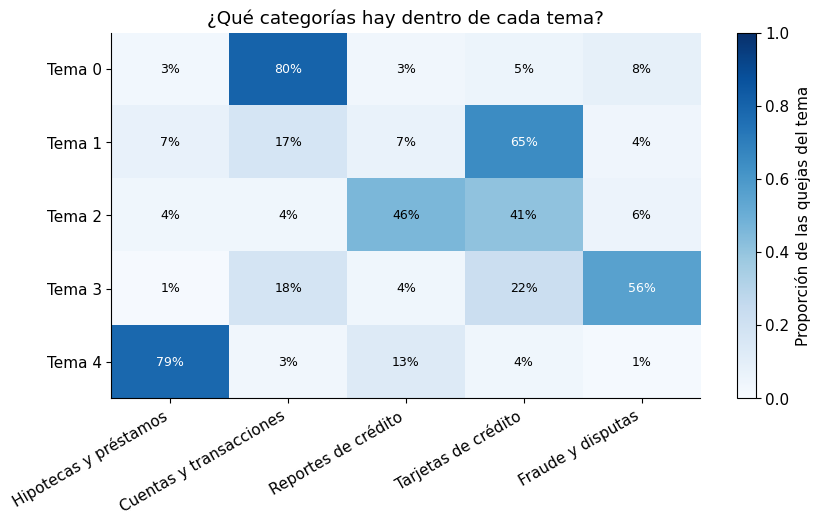

In [32]:
# Proporción de cada categoría dentro de cada tema (cada fila suma 100 %)
proporciones = quejas_por_tema_y_categoria.div(quejas_por_tema_y_categoria.sum(axis=1), axis=0)
dibujar_heatmap(proporciones.values, [f"Tema {k}" for k in proporciones.index], CATEGORIAS,
                "¿Qué categorías hay dentro de cada tema?", "Proporción de las quejas del tema")
plt.show()

✅ **Punto de control:** sin una sola etiqueta, descubriste los grandes temas de las quejas, elegiste el mejor modelo
de forma honesta y les pusiste nombre de negocio. Ahora cada queja de entrenamiento tiene una etiqueta: su tema.

## 🎓 Paso 6: Entrenar un clasificador

LDA ya etiquetó las quejas históricas. Pero cuando llegue una **queja nueva**, queremos una respuesta **inmediata**
y con **probabilidades**. Para eso entrenamos un **clasificador**.

### Regresión Logística multiclase

Calcula un puntaje por cada clase y lo convierte en probabilidades con la función **softmax**:

$$P(y = k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^\top \mathbf{x} + b_k}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^\top \mathbf{x} + b_j}}$$

- $\mathbf{x}$ es el vector TF-IDF de la queja; $\mathbf{w}_k$ tiene **un peso por término** para la clase $k$.
- Entrenar es buscar los pesos que minimizan la **entropía cruzada** (qué tan mal predice) más una penalización de
  **regularización** (controlada por $C$). Esa penalización evita pesos exagerados y, con ellos, el *sobreajuste*.
- Su gran ventaja es que es **interpretable**: los pesos más altos dicen qué palabras empujan hacia cada clase.

### Un Pipeline: todos los pasos en un solo objeto

Un `Pipeline` de scikit-learn encadena **vectorizar → TF-IDF → clasificar**. Al llamar `fit`, cada paso aprende solo
de los datos de entrenamiento. Al llamar `predict`, todos se aplican en orden. Así es imposible cometer fuga de datos
por descuido, y el modelo completo se puede guardar y usar con quejas nuevas.

### ¿Cómo sabemos si funciona?

| Métrica | Fórmula | Pregunta que responde |
| --- | --- | --- |
| Accuracy | $\frac{\text{aciertos}}{\text{total}}$ | ¿Qué fracción acerté? |
| Precision | $\frac{TP}{TP + FP}$ | De lo que envié al equipo X, ¿cuánto era realmente de X? |
| Recall | $\frac{TP}{TP + FN}$ | De lo que era de X, ¿cuánto le llegó a X? |
| F1 | $2 \cdot \frac{P \cdot R}{P + R}$ | Balance entre precision y recall |
| F1 macro | Promedio simple del F1 de cada clase | ¿Funciona bien **en todas** las clases, incluso las pequeñas? |
| F1 ponderado | Promedio del F1 de cada clase, ponderado por su tamaño | Un solo número, justo con clases desbalanceadas |

La **matriz de confusión** muestra, para cada clase real (filas), qué predijo el modelo (columnas). La diagonal son
los aciertos; todo lo que está fuera de ella son quejas mal enrutadas.

In [33]:
modelo_a = Pipeline([
    ("conteos", CountVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.5, max_features=20000)),
    ("tfidf", TfidfTransformer()),
    # C=10 significa regularización suave: el modelo puede usar pesos grandes si le ayudan
    ("clasificador", LogisticRegression(max_iter=1000, C=10)),
])
modelo_a.fit(quejas.lemas[idx_entrenamiento], temas_entrenamiento)

temas_predichos = modelo_a.predict(quejas.lemas[idx_prueba])
nombres_temas = [f"Tema {k}: {CATEGORIAS[TEMA_A_CATEGORIA[k]]}" for k in range(NUM_TEMAS)]
print(classification_report(temas_prueba, temas_predichos, target_names=nombres_temas, digits=3))

                                 precision    recall  f1-score   support

Tema 0: Cuentas y transacciones      0.941     0.955     0.948      1863
    Tema 1: Tarjetas de crédito      0.904     0.901     0.903       817
    Tema 2: Reportes de crédito      0.935     0.937     0.936      1269
      Tema 3: Fraude y disputas      0.937     0.917     0.927      1063
  Tema 4: Hipotecas y préstamos      0.945     0.941     0.943      1310

                       accuracy                          0.935      6322
                      macro avg      0.932     0.930     0.931      6322
                   weighted avg      0.935     0.935     0.935      6322



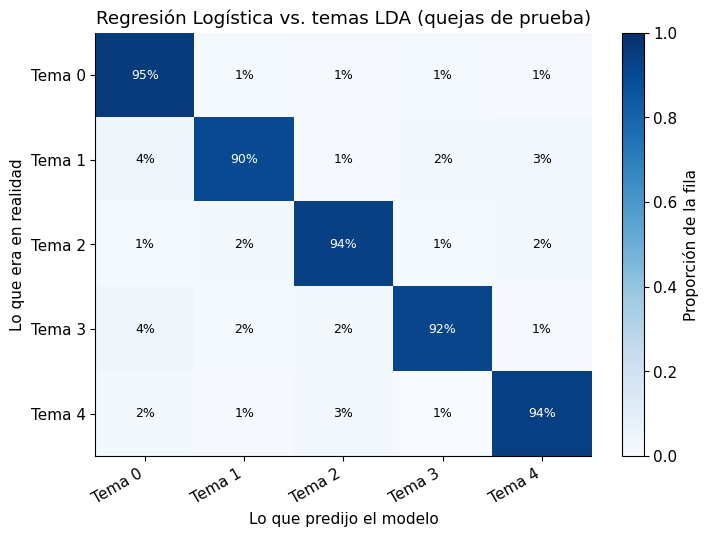

In [34]:
def graficar_matriz_confusion(reales, predichas, nombres, titulo):
    # Normalizamos por fila: cada celda dice qué % de la clase real se predijo como cada clase
    matriz = confusion_matrix(reales, predichas, labels=range(len(nombres)), normalize="true")
    fig, ax = plt.subplots(figsize=(8, 5.5))
    dibujar_heatmap(matriz, nombres, nombres, titulo, "Proporción de la fila", ax=ax)
    ax.set_xlabel("Lo que predijo el modelo")
    ax.set_ylabel("Lo que era en realidad")
    plt.show()


graficar_matriz_confusion(temas_prueba, temas_predichos, [f"Tema {k}" for k in range(NUM_TEMAS)],
                          "Regresión Logística vs. temas LDA (quejas de prueba)")

👀 **Qué observar:** el acierto contra los temas LDA es muy alto, ~90 %. ¡Cuidado! Eso **no** significa que
enrute bien. LDA y la Regresión Logística miran las mismas palabras, así que el clasificador aprende a *imitar* a LDA.
Es una **evaluación circular**, un error frecuente en proyectos de este tipo: muchos reportan 90 % o más exactamente
así.

La pregunta que le importa al banco es otra: **¿los temas coinciden con la realidad?** Eso lo mediremos en el paso 7,
contra la categoría de referencia.

### 🔎 ¿Qué aprendió el modelo?

Una ventaja de la Regresión Logística: podemos abrirla y ver qué palabras empujan hacia cada tema.

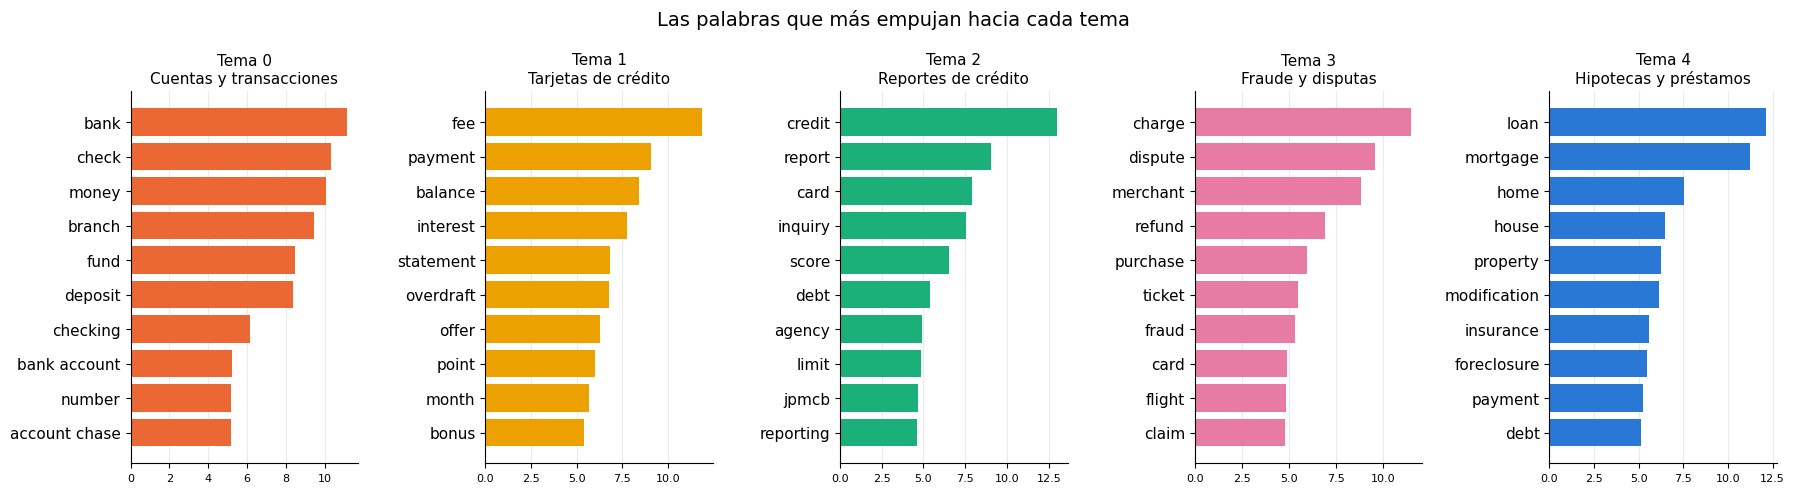

In [35]:
vocabulario_modelo = modelo_a.named_steps["conteos"].get_feature_names_out()
pesos_por_tema = modelo_a.named_steps["clasificador"].coef_      # una fila de pesos por tema

fig, ejes = plt.subplots(1, NUM_TEMAS, figsize=(18, 5))
for tema, ax in enumerate(ejes):
    top = pesos_por_tema[tema].argsort()[::-1][:10]                # los 10 términos con más peso positivo
    ax.barh(vocabulario_modelo[top][::-1], pesos_por_tema[tema][top][::-1],
            color=colores_temas[tema])
    ax.set_title(f"Tema {tema}\n{CATEGORIAS[TEMA_A_CATEGORIA[tema]]}", fontsize=11)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Las palabras que más empujan hacia cada tema", fontsize=14)
plt.tight_layout()
plt.show()

✅ **Punto de control:** tienes un clasificador rápido e interpretable, entrenado **sin ninguna etiqueta humana**.

## ⚔️ Paso 7: Tu modelo contra un modelo de IA pre-entrenado

La gerente te pregunta: *"¿Y no sería más fácil usar uno de esos modelos de IA que ya vienen entrenados?"*
Buena pregunta. Vamos a averiguarlo.

### Modelos pre-entrenados y zero-shot

Hasta ahora construimos todo desde cero con nuestros datos. La alternativa moderna es usar **modelos
pre-entrenados**: redes *Transformer* entrenadas con millones de textos, que ya "entienden" el idioma. Un modelo
**zero-shot** clasifica en categorías que **nunca vio durante su entrenamiento**, porque recibe los nombres de las
categorías como texto. No necesita etiquetas ni entrenamiento, que era justo nuestro problema.

### Cómo funciona un clasificador zero-shot NLI

**NLI (Natural Language Inference)** es la tarea de decidir si una frase (*premisa*) implica otra (*hipótesis*).
El truco zero-shot convierte cada categoría en una hipótesis:

- **Premisa:** la queja.
- **Hipótesis:** *"This complaint is about {descripción de la categoría}."*

El modelo calcula qué tan probable es que la queja **implique** cada una de las 5 hipótesis, y gana la más alta. Son
5 pasadas por el modelo para cada queja.

Usamos **`MoritzLaurer/deberta-v3-large-zeroshot-v2.0`** (Laurer et al., 2024). En 28 tareas de clasificación supera
con claridad al clásico `facebook/bart-large-mnli` (F1 macro promedio 0,68 frente a 0,50).

| | A. Tu modelo | B. DeBERTa-v3 zero-shot |
| --- | --- | --- |
| Tipo | TF-IDF + Regresión Logística | Transformer NLI |
| Parámetros | ~100 mil pesos | ~435 millones |
| ¿Necesita etiquetas? | No (usa los temas de LDA) | No |
| Hardware | CPU | GPU |
| Interpretabilidad | Alta (pesos por palabra) | Baja |

### Reglas del duelo

- Los dos modelos clasifican las **mismas 500 quejas** del conjunto de prueba.
- Ambos se evalúan contra la **categoría de referencia**, que ninguno vio.
- Medimos **accuracy**, **F1 ponderado**, **F1 macro**, **F1 por categoría** y **segundos por cada 100 quejas**.

In [36]:
TAMANO_DUELO = 500
duelo = quejas.loc[idx_prueba].sample(TAMANO_DUELO, random_state=42)
categorias_reales = duelo.categoria_ref.tolist()

resultados = {}          # métricas generales de cada modelo
f1_por_categoria = {}    # F1 de cada categoría para cada modelo


def evaluar(nombre_modelo, categorias_predichas, segundos):
    # Calcula las métricas, las guarda y dibuja la matriz de confusión
    resultados[nombre_modelo] = {
        "accuracy": accuracy_score(categorias_reales, categorias_predichas),
        "f1_ponderado": f1_score(categorias_reales, categorias_predichas, average="weighted"),
        "f1_macro": f1_score(categorias_reales, categorias_predichas, average="macro"),
        "segundos_por_100": segundos / len(categorias_predichas) * 100,
    }
    f1_por_categoria[nombre_modelo] = f1_score(categorias_reales, categorias_predichas,
                                               average=None, labels=range(len(CATEGORIAS)))
    print(nombre_modelo, {metrica: round(valor, 3) for metrica, valor in resultados[nombre_modelo].items()})
    graficar_matriz_confusion(categorias_reales, categorias_predichas, CATEGORIAS,
                              f"{nombre_modelo} vs. referencia")

### 🅰️ Tu modelo: spaCy + TF-IDF + Regresión Logística

Medimos el tiempo del **camino completo**, desde el texto crudo hasta la categoría, tal como funcionaría en el banco:
limpiar → spaCy → Pipeline (TF-IDF + Regresión Logística) → traducir el tema a categoría.

A. Tu modelo (LDA + LR) {'accuracy': 0.654, 'f1_ponderado': 0.648, 'f1_macro': 0.605, 'segundos_por_100': 1.171}


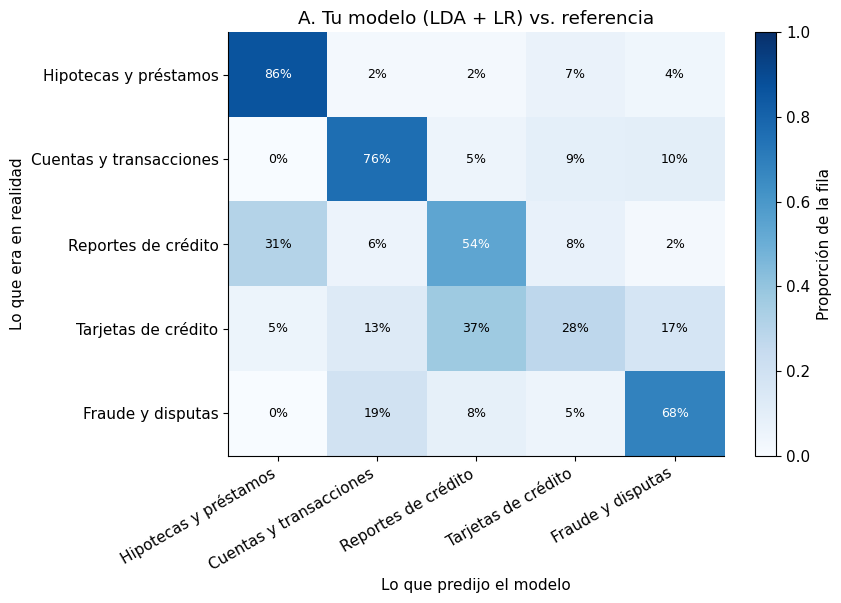

In [37]:
inicio = time.time()

lemas_duelo = extraer_lemas(limpiar_texto(duelo.texto_original))
probabilidades_a = modelo_a.predict_proba(lemas_duelo)          # una fila por queja, una columna por tema
temas_duelo = probabilidades_a.argmax(axis=1)
predicciones_a = [TEMA_A_CATEGORIA[tema] for tema in temas_duelo]

evaluar("A. Tu modelo (LDA + LR)", predicciones_a, time.time() - inicio)

### 🔍 Aprender de los errores

Un buen análisis no solo mira el número final: **lee los errores**. Estas son tres quejas que tu modelo envió al área
equivocada. ¿El modelo se equivocó, o la queja es ambigua? ¿Quizás el cliente marcó mal el producto?

In [38]:
errores = [i for i in range(TAMANO_DUELO) if predicciones_a[i] != categorias_reales[i]]
print(f"Errores: {len(errores)} de {TAMANO_DUELO}\n")
for i in errores[:3]:
    queja = duelo.iloc[i]
    confianza = probabilidades_a[i].max()
    print(f"Referencia: {CATEGORIAS[categorias_reales[i]]}  →  Tu modelo: {CATEGORIAS[predicciones_a[i]]} "
          f"(confianza {confianza:.0%})")
    print(f"Producto marcado: {queja.producto} | Problema: {queja.problema}")
    print(f"  {queja.texto_original[:500]}\n")

Errores: 173 de 500

Referencia: Tarjetas de crédito  →  Tu modelo: Reportes de crédito (confianza 100%)
Producto marcado: Credit card | Problema: Credit determination
  Hi, I just recently tried to get a credit card from amazon. The credit card is through Chase and I first before I apply checked the internet about what you credit score had to be many site 's said it had to be in the fair range. I have to credit cards now and the cards are somewhat max out, but I 'm saving for a house and I ca n't use that money to pay them. I make around {$33000.00} per year.I called to see if I was approved and they got more info from me but they did n't approve me, but I thin

Referencia: Fraude y disputas  →  Tu modelo: Cuentas y transacciones (confianza 66%)
Producto marcado: Money transfer, virtual currency, or money service | Problema: Fraud or scam
  Received a XXXX request on Chase bank on the XXXX XX/XX/2018 for {$300.00} from an unknown party. Accidentally accepted the request later that eve

### 🅱️ DeBERTa-v3 zero-shot

El `pipeline` de Hugging Face descarga el modelo (~0,9 GB) y hace todo el proceso NLI por dentro. `device=0` le dice
que use la GPU, y `float16` usa la mitad de memoria con casi la misma precisión.

#### Mini-experimento: ¿importa cómo nombramos las categorías?

Un modelo zero-shot solo conoce las categorías **por su nombre**. Probemos con 100 quejas: nombres cortos vs.
**descripciones** que explican qué entra en cada categoría.

In [39]:
import torch
from transformers import pipeline

clasificador_zero_shot = pipeline("zero-shot-classification",
                                  model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0",
                                  device=0, torch_dtype=torch.float16)
HIPOTESIS = "This complaint is about {}."

# Descripciones de cada categoría, en el mismo orden que CATEGORIAS
DESCRIPCIONES_EN = [
    "a mortgage or a loan (home, car, student or personal loan)",
    "a checking or savings account: deposits, withdrawals, transfers, checks or account closure",
    "a credit report, a credit inquiry or a debt collector",
    "a credit card: fees, interest, balance, payments, rewards or a card application",
    "fraud, a scam, identity theft or a charge the customer did not authorize",
]

# Los Transformers tienen un límite de longitud: recortamos cada queja a 2.000 caracteres
textos_duelo = [texto[:2000] for texto in duelo.texto_original]


def clasificar_zero_shot(textos, etiquetas):
    respuestas = clasificador_zero_shot(textos, candidate_labels=etiquetas, hypothesis_template=HIPOTESIS,
                                        batch_size=8, truncation=True)
    # "labels" viene ordenado de mayor a menor probabilidad: el primero es la predicción
    return [etiquetas.index(r["labels"][0]) for r in respuestas]


for nombre, etiquetas in [("Nombres cortos", CATEGORIAS_EN), ("Descripciones", DESCRIPCIONES_EN)]:
    predicciones = clasificar_zero_shot(textos_duelo[:100], etiquetas)
    print(f"{nombre:15s} accuracy en 100 quejas: {accuracy_score(categorias_reales[:100], predicciones):.2f}")

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

Nombres cortos  accuracy en 100 quejas: 0.63
Descripciones   accuracy en 100 quejas: 0.73


👀 **Qué observar:** las descripciones ayudan mucho. Este es el corazón del **prompt engineering**: el modelo es el
mismo, pero le explicamos mejor la tarea. Usamos las descripciones para el duelo completo.

B. DeBERTa-v3 zero-shot {'accuracy': 0.692, 'f1_ponderado': 0.7, 'f1_macro': 0.673, 'segundos_por_100': 16.739}


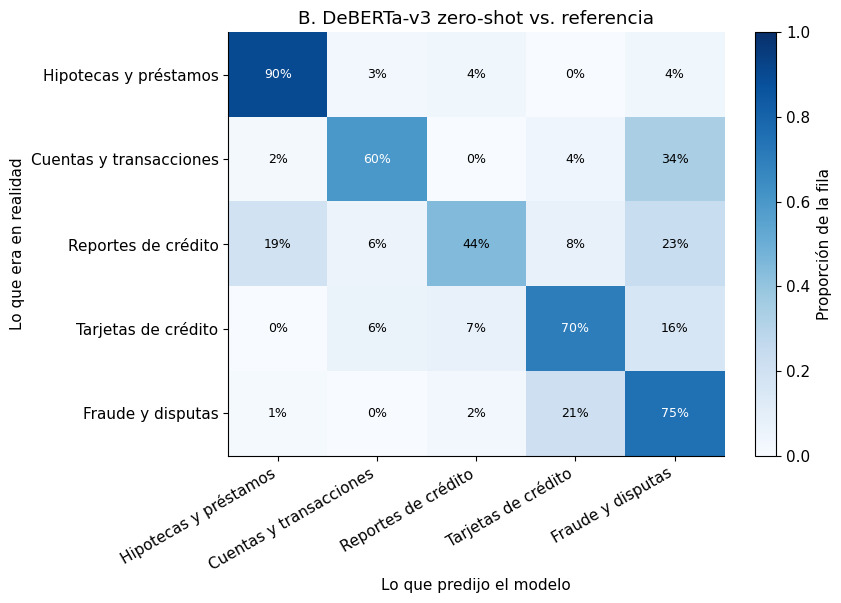

In [40]:
inicio = time.time()
predicciones_b = clasificar_zero_shot(textos_duelo, DESCRIPCIONES_EN)
evaluar("B. DeBERTa-v3 zero-shot", predicciones_b, time.time() - inicio)
# No liberamos el modelo: lo usará la app del paso 9

## 🏁 Paso 8: El veredicto

In [41]:
resumen = pd.DataFrame(resultados).T
resumen["necesita_etiquetas"] = ["No (temas de LDA)", "No"]
resumen.round(3)

,accuracy,f1_ponderado,f1_macro,segundos_por_100,necesita_etiquetas
A. Tu modelo (LDA + LR),0.654,0.648,0.605,1.171,No (temas de LDA)
B. DeBERTa-v3 zero-shot,0.692,0.700,0.673,16.739,No


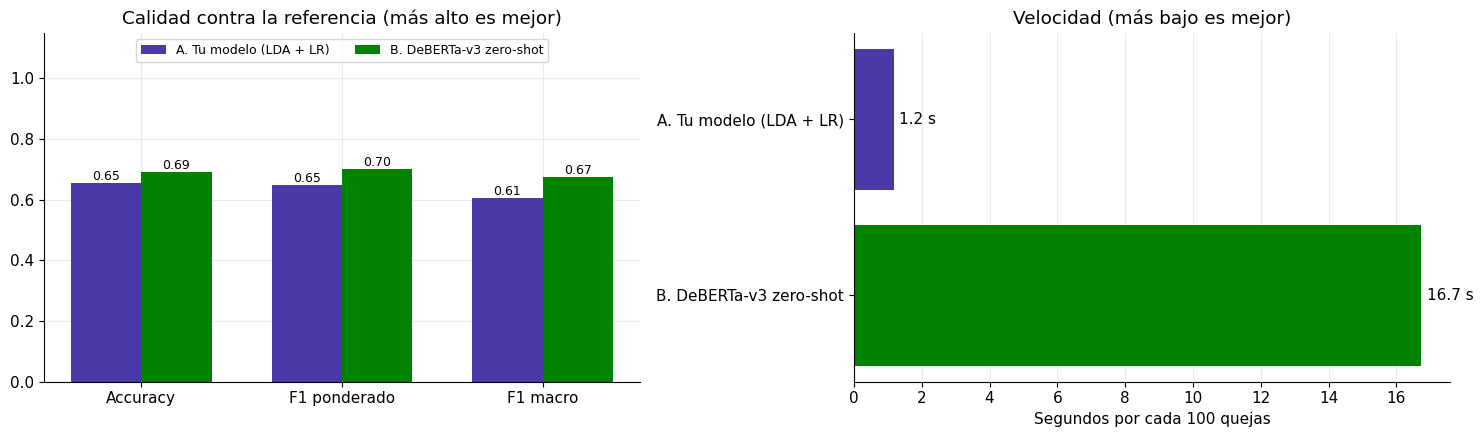

In [42]:
COLORES_MODELOS = ["#4a3aa7", "#008300"]   # A: violeta, B: verde
modelos = list(resultados)
metricas = ["accuracy", "f1_ponderado", "f1_macro"]
fig, (ax_calidad, ax_velocidad) = plt.subplots(1, 2, figsize=(15, 4.5))

# Calidad: tres métricas en la misma escala de 0 a 1
posiciones = np.arange(len(metricas))
ancho = 0.35
for i, modelo in enumerate(modelos):
    valores = [resultados[modelo][m] for m in metricas]
    barras = ax_calidad.bar(posiciones + (i - 0.5) * ancho, valores, ancho, label=modelo, color=COLORES_MODELOS[i])
    ax_calidad.bar_label(barras, fmt="%.2f", fontsize=9)
ax_calidad.set_xticks(posiciones, ["Accuracy", "F1 ponderado", "F1 macro"])
ax_calidad.set_ylim(0, 1.15)
ax_calidad.set_title("Calidad contra la referencia (más alto es mejor)")
ax_calidad.legend(loc="upper center", ncol=2, fontsize=9)

# Velocidad: va en otra gráfica porque la unidad es distinta (segundos)
tiempos = [resultados[modelo]["segundos_por_100"] for modelo in modelos]
barras = ax_velocidad.barh(modelos, tiempos, color=COLORES_MODELOS)
ax_velocidad.bar_label(barras, fmt="%.1f s", padding=4)
ax_velocidad.invert_yaxis()
ax_velocidad.grid(axis="y", visible=False)
ax_velocidad.set_xlabel("Segundos por cada 100 quejas")
ax_velocidad.set_title("Velocidad (más bajo es mejor)")

plt.tight_layout()
plt.show()

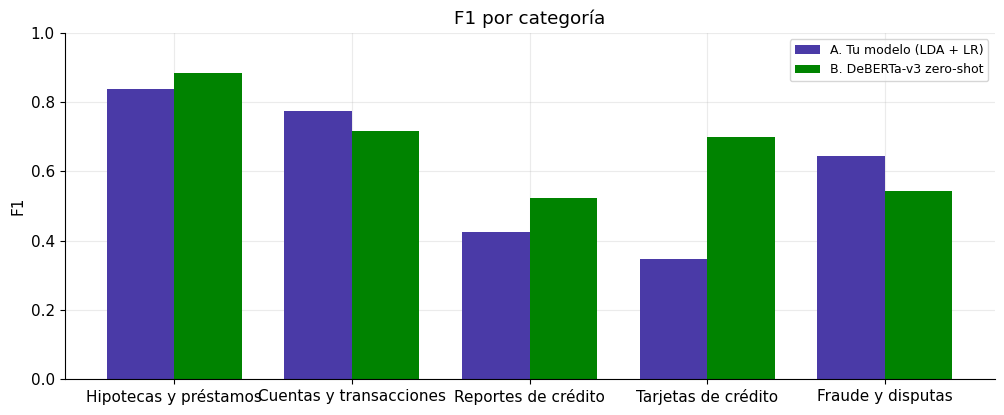

In [43]:
# ¿En qué categorías gana cada modelo?
fig, ax = plt.subplots(figsize=(12, 4.5))
posiciones = np.arange(len(CATEGORIAS))
ancho = 0.38
for i, modelo in enumerate(modelos):
    ax.bar(posiciones + (i - 0.5) * ancho, f1_por_categoria[modelo], ancho, label=modelo, color=COLORES_MODELOS[i])
ax.set_xticks(posiciones, CATEGORIAS)
ax.set_ylim(0, 1)
ax.set_ylabel("F1")
ax.set_title("F1 por categoría")
ax.legend(fontsize=9)
plt.show()

## 📝 Tu recomendación a la gerente

Escribe tu respuesta al correo del primer día. Usa **tus** resultados y estas preguntas como guía:
0. 

1. **Calidad:** ¿qué modelo coincide más con la referencia? ¿Qué categorías se confunden más? ¿Tiene sentido esa
   confusión para el negocio? (Por ejemplo: un cobro que el cliente no reconoce en su tarjeta, ¿es de *Tarjetas* o de
   *Fraude*?)
2. **Evaluación honesta:** tu modelo acierta ~90 % contra los temas de LDA, pero bastante menos contra la referencia.
   ¿Cuál de los dos números le reportarías a la gerente? ¿Por qué?
3. **Etiquetas:** ninguno de los dos modelos usó etiquetas humanas. Tu modelo dependió de que LDA encontrara temas
   parecidos a las áreas del banco; DeBERTa solo necesitó una buena *descripción* de cada área. ¿Qué pasa si mañana el
   banco crea una sexta área?
4. **Costo y velocidad:** tu modelo corre en CPU en milisegundos por queja. DeBERTa necesita GPU. Para decenas de
   miles de quejas al año, ¿importa la diferencia?
5. **Explicabilidad:** si un auditor pregunta por qué una queja fue a cierto equipo, ¿con cuál modelo puedes
   responder mejor?
6. **Sesgo:** tus datos solo incluyen quejas de clientes que dieron consentimiento, desde 2015. ¿Funcionaría igual con
   quejas que llegan por teléfono?
7. **Tu propuesta:** una opción híbrida muy usada es dejar que el modelo rápido enrute las quejas **claras** y mandar
   a revisión humana (o a DeBERTa) solo las de **baja confianza**.
9. 


## 🚀 Retos extra
- **Entrena otro modelo y prueba un modelo preentrenado diferente** Random forest, árboles de decisión, XGBoost, Redes neuronales (Nivel PRO) El nuevo modelo mejoró con respecto a la regresión?, para el modelo preentrenado, búscalo en HuggingFace
- **Prueba el nuevo modelo JEV**  https://typesafe.ai/blog/introducing-system-one-models-and-jev
- **Más temas:** cambia `NUM_TEMAS` a 8 y asigna varios temas a la misma categoría. ¿Mejora el acierto?
- **Otra semilla:** usa la semilla de **mayor** perplejidad en vez de la menor. ¿Cuánto cambia el resultado final?
- **Etiquetas reales:** entrena el Pipeline con `categoria_ref` en vez de los temas. ¿Cuánto mejora? ¿Cuánto valdría
  para el banco etiquetar quejas a mano?
- **Prompt engineering:** cambia `HIPOTESIS` o reescribe `DESCRIPCIONES_EN`. ¿Puedes mejorar a DeBERTa?
- **Confianza:** usa `probabilidades_a` para enrutar automáticamente solo las quejas con probabilidad mayor a 0,8.
  ¿Qué porcentaje queda para revisión humana, y con qué accuracy?

## 🖥️ Paso 9: Una app para el equipo de Servicio al Cliente

Ahora creemos una interfaz web!

Usamos **[Gradio](https://www.gradio.app/)**, una librería que convierte una función de Python en una interfaz web
con muy pocas líneas:

1. Escribimos una función `clasificar_queja(texto)` que devuelve las probabilidades de cada modelo.
2. Gradio dibuja la caja de texto, el botón y los resultados, y llama a la función cada vez que alguien pulsa el
   botón.

> 🌐 En Kaggle, `share=True` crea un enlace público temporal (dura unas horas) para abrir la app en otra pestaña o
> compartirla con tus compañeros.

In [44]:
!pip install -q gradio

In [45]:
import gradio as gr


def probabilidades_modelo_a(texto):
    # Mismo camino que en el duelo: limpiar → spaCy → Pipeline. Con una sola queja basta 1 proceso.
    lemas = extraer_lemas(limpiar_texto(pd.Series([texto])), procesos=1)
    probabilidades_temas = modelo_a.predict_proba(lemas)[0]
    # Varios temas pueden apuntar a la misma categoría: sumamos sus probabilidades
    por_categoria = {categoria: 0.0 for categoria in CATEGORIAS}
    for tema, probabilidad in zip(modelo_a.classes_, probabilidades_temas):
        por_categoria[CATEGORIAS[TEMA_A_CATEGORIA[tema]]] += probabilidad
    return por_categoria


def probabilidades_modelo_b(texto):
    respuesta = clasificador_zero_shot(texto[:2000], candidate_labels=DESCRIPCIONES_EN,
                                       hypothesis_template=HIPOTESIS, truncation=True)
    # Traducimos cada descripción en inglés al nombre de la categoría en español
    return {CATEGORIAS[DESCRIPCIONES_EN.index(etiqueta)]: puntaje
            for etiqueta, puntaje in zip(respuesta["labels"], respuesta["scores"])}


def clasificar_queja(texto):
    if not texto or not texto.strip():
        raise gr.Error("Escribe o pega una queja primero.")
    return probabilidades_modelo_a(texto), probabilidades_modelo_b(texto)


# Probamos la función antes de construir la app
prueba = "Someone used my credit card to buy plane tickets I never purchased and Chase refuses to refund me."
a, b = clasificar_queja(prueba)
print("A:", max(a, key=a.get), "| B:", max(b, key=b.get))

A: Fraude y disputas | B: Fraude y disputas


In [46]:
EJEMPLOS = [
    "Someone used my credit card to buy plane tickets I never purchased and Chase refuses to refund me.",
    "I applied for a loan modification on my mortgage six months ago and Chase keeps losing my documents.",
    "There is a hard inquiry from Chase on my credit report that I never authorized. Please remove it.",
    "Chase closed my checking account without notice and is holding my direct deposit.",
    "I paid my credit card balance in full but Chase still charged me interest and a late fee.",
]

with gr.Blocks(title="Enrutador de quejas") as app:
    gr.Markdown("# 🏦 Enrutador de quejas\nPega una queja (en inglés) y mira a qué área la enviaría cada modelo.")
    entrada = gr.Textbox(label="Queja del cliente", lines=6, placeholder="Describe what happened...")
    boton = gr.Button("Clasificar", variant="primary")
    with gr.Row():
        salida_a = gr.Label(label="A. Tu modelo (LDA + Regresión Logística)", num_top_classes=5)
        salida_b = gr.Label(label="B. DeBERTa-v3 zero-shot", num_top_classes=5)
    gr.Examples(EJEMPLOS, inputs=entrada)
    # Al pulsar el botón, Gradio llama a clasificar_queja con el texto y pinta las dos salidas
    boton.click(clasificar_queja, inputs=entrada, outputs=[salida_a, salida_b])

app.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://840ea300a168cac94b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


🕵️ **Tu turno:** prueba la app con quejas difíciles. Por ejemplo, un cobro de tarjeta que el cliente no reconoce:
¿es *Tarjetas* o *Fraude*? ¿En qué casos los dos modelos no están de acuerdo? Esas son las quejas que conviene enviar
a revisión humana.

Cuando termines, detén la app con `app.close()`.

## 📖 Glosario

| Término | Definición |
| --- | --- |
| EDA | Análisis exploratorio: conocer los datos antes de modelar |
| Sesgo de selección | Cuando los datos analizados no representan a toda la población |
| Token | Unidad mínima de texto, normalmente una palabra |
| Lema | Forma base de una palabra (`charged` → `charge`) |
| POS | *Part of Speech*: función gramatical de una palabra |
| N-grama | Secuencia de n palabras seguidas |
| Frecuencia documental | Porcentaje de documentos que contienen una palabra |
| TF-IDF | Peso que premia términos frecuentes en un documento y raros en el resto |
| Fuga de datos | Usar, sin querer, información de los datos de prueba durante el entrenamiento |
| LDA | Modelo probabilístico no supervisado que descubre temas |
| Perplejidad | Qué tan "sorprendido" queda un modelo de temas con los textos; menor es mejor |
| Distancia de Hellinger | Forma de comparar distribuciones de probabilidad (raíz cuadrada + distancia normal) |
| t-SNE | Técnica para dibujar datos de muchas dimensiones en 2D, conservando los vecinos |
| Softmax | Función que convierte puntajes en probabilidades que suman 1 |
| Evaluación circular | Evaluar un modelo contra etiquetas que salieron de los mismos datos y el mismo método |
| Zero-shot | Clasificar en categorías sin ejemplos de entrenamiento de esas categorías |
| NLI | Inferencia de lenguaje natural: ¿la premisa implica la hipótesis? |

### 📚 Referencias

- Blei, Ng y Jordan (2003). *Latent Dirichlet Allocation.* JMLR.
- Martin y Johnson (2015). *More Efficient Topic Modelling Through a Noun Only Approach.* ALTA.
- Laurer et al. (2024). *Building Efficient Universal Classifiers with Natural Language Inference.* arXiv:2312.17543.
- van der Maaten y Hinton (2008). *Visualizing Data using t-SNE.* JMLR.
- CFPB. *Consumer Complaint Database.* consumerfinance.gov/data-research/consumer-complaints